In [1261]:
import pandas as pd
import numpy as np
df=pd.read_csv("E:/Luminar/Machine_Learning/World_cup_prediction_model/International football results/results.csv")


In [1262]:
df[df['tournament']=='FIFA World Cup']

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
1490,1930-07-13,Belgium,United States,0.0,3.0,FIFA World Cup,Montevideo,Uruguay,True
1491,1930-07-13,France,Mexico,4.0,1.0,FIFA World Cup,Montevideo,Uruguay,True
1492,1930-07-14,Brazil,Yugoslavia,1.0,2.0,FIFA World Cup,Montevideo,Uruguay,True
1493,1930-07-14,Peru,Romania,1.0,3.0,FIFA World Cup,Montevideo,Uruguay,True
1494,1930-07-15,Argentina,France,1.0,0.0,FIFA World Cup,Montevideo,Uruguay,True
...,...,...,...,...,...,...,...,...,...
49472,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49473,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49474,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49475,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True


In [1263]:
df["date"].min(),df["date"].max()
# df.isna().sum()

('1872-11-30', '2026-06-27')

In [1264]:
df[df["home_score"].isna()]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49409,2026-06-13,Qatar,Switzerland,NaN,NaN,FIFA World Cup,Santa Clara,United States,True
49410,2026-06-13,Brazil,Morocco,NaN,NaN,FIFA World Cup,East Rutherford,United States,True
49411,2026-06-13,Haiti,Scotland,NaN,NaN,FIFA World Cup,Foxborough,United States,True
49412,2026-06-13,Australia,Turkey,NaN,NaN,FIFA World Cup,Vancouver,Canada,True
49413,2026-06-14,Germany,Curaçao,NaN,NaN,FIFA World Cup,Houston,United States,True
...,...,...,...,...,...,...,...,...,...
49472,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49473,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49474,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49475,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True


In [1265]:
def get_result(row):
    if row['home_score']>row['away_score']:
        return "H"#home
    elif row['home_score']<row['away_score']:
        return "A"#away
    else:
        return "D"#draw
df['result'] = df.apply(get_result, axis=1)
df['result'].value_counts()
# df.iloc[1655:1700]

result
H    24215
A    13960
D    11302
Name: count, dtype: int64

In [1266]:
df['country'].nunique()

269

In [1267]:
df["goal_difference"]=df["home_score"]-df["away_score"]
df["date"].dtype
df['date']=pd.to_datetime(df['date'])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

In [1268]:
historical_df=df[df['home_score'].notna()].copy()
upcoming_df=df[df['home_score'].isna()].copy()

historical_df=historical_df[historical_df['date']>='2000-01-01']
# Remove 2026 World Cup matches from historical data
historical_df = historical_df[
    ~(
        (historical_df["tournament"] == "FIFA World Cup") &
        (historical_df["date"] >= "2026-06-01")
    )
].copy()
wc_matches = df[
    (df["tournament"] == "FIFA World Cup") &
    (df["date"] >= "2026-06-01") &
    (df["home_score"].notna())
].copy()
wc_matches["home_score"] = np.nan
wc_matches["away_score"] = np.nan
wc_matches["result"] = np.nan
upcoming_df = pd.concat(
    [wc_matches, upcoming_df],
    ignore_index=True
)
upcoming_df = (
    upcoming_df
    .sort_values("date")
    .reset_index(drop=True)
)
print(len(historical_df))
print(len(upcoming_df))

upcoming_df.head()

25343
72


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,goal_difference,year,month
0,2026-06-11,Mexico,South Africa,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False,NaN,2.0,2026,6
1,2026-06-11,South Korea,Czech Republic,NaN,NaN,FIFA World Cup,Zapopan,Mexico,True,NaN,1.0,2026,6
2,2026-06-12,Canada,Bosnia and Herzegovina,NaN,NaN,FIFA World Cup,Toronto,Canada,False,NaN,0.0,2026,6
3,2026-06-12,United States,Paraguay,NaN,NaN,FIFA World Cup,Inglewood,United States,False,NaN,3.0,2026,6
4,2026-06-13,Qatar,Switzerland,NaN,NaN,FIFA World Cup,Santa Clara,United States,True,D,NaN,2026,6


In [1269]:
print("Historical matches:", historical_df.shape)
print("Upcoming WC matches:", upcoming_df.shape)

Historical matches: (25343, 13)
Upcoming WC matches: (72, 13)


In [1270]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# india=df[((df['home_team']=='India')|(df['away_team']=='India') & (df['home_score'].notna()))].copy()
# def india_result(row):
#     if row['home_team']=='India':
#         if row['home_score']>row['away_score']:
#             return "Win"
#         elif row['home_score']<row['away_score']:
#             return "Loss"
#         else: return "Draw"
#     else:
#         if row['away_score']>row['home_score']:
#             return "Win"
#         elif row['away_score']<row['home_score']:
#             return "Loss"
#         else: return "Draw"

# india["India_result"]=india.apply(india_result,axis=1)
# print("Total India Matches:",len(india))
# print(india['India_result'].value_counts())


In [1271]:
# plt.figure(figsize=(8,5))
# counts = india['India_result'].value_counts()
# counts = counts.reindex(['Win', 'Loss', 'Draw'])
# colors=['green','red','gray']
# counts.plot(kind='bar',color=colors)
# plt.title("Indian Football Results all time")
# plt.xlabel("Result")
# plt.ylabel("Number of Matches")
# plt.xticks(rotation=0)
# plt.tight_layout()
# plt.show()

In [1272]:

# india['year'] = india['date'].dt.year

# yearly = india.groupby(['year', 'India_result']).size().unstack(fill_value=0)
# yearly.plot(kind='bar', figsize=(15, 5), color=['gray', 'red', 'green'])

# plt.title("India Football Results Year by Year")
# plt.xlabel("Year")
# plt.ylabel("Number of Matches")
# plt.legend(title="Result")
# plt.tight_layout()
# plt.show()

In [1273]:
print(historical_df.shape)
print(upcoming_df.shape)

(25343, 13)
(72, 13)


In [1274]:
historical_df=historical_df.sort_values("date").reset_index(drop=True)
historical_df

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,goal_difference,year,month
0,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,Aswan,Egypt,False,H,1.0,2000,1
1,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,Tunis,Tunisia,False,H,7.0,2000,1
2,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,Port of Spain,Trinidad and Tobago,False,D,0.0,2000,1
3,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Friendly,Ouagadougou,Burkina Faso,False,D,0.0,2000,1
4,2000-01-09,Guatemala,Armenia,1.0,1.0,Friendly,Los Angeles,United States,True,D,0.0,2000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25338,2026-06-09,Hungary,Kazakhstan,3.0,1.0,Friendly,Debrecen,Hungary,False,H,2.0,2026,6
25339,2026-06-10,Portugal,Nigeria,2.0,1.0,Friendly,Leiria,Portugal,False,H,1.0,2026,6
25340,2026-06-10,Bolivia,Algeria,0.0,4.0,Friendly,Kansas City,United States,True,A,-4.0,2026,6
25341,2026-06-10,England,Costa Rica,3.0,0.0,Friendly,Orlando,United States,True,H,3.0,2026,6


In [1275]:
def get_team_form(team, date, df, n=10):

    past = df[
        (
            (df['home_team'] == team) |
            (df['away_team'] == team)
        ) &
        (df['date'] < date)
    ].tail(n)

    if len(past) == 0:
        return 0, 0, 0, 0, 0

    goal_scored = []
    goal_conceded = []
    goal_difference = []
    wins = []
    draws = []

    for _, row in past.iterrows():

        if row['home_team'] == team:

            scored = row['home_score']
            conceded = row['away_score']

            goal_scored.append(scored)
            goal_conceded.append(conceded)
            goal_difference.append(scored - conceded)

            wins.append(1 if row['result'] == 'H' else 0)
            draws.append(1 if row['result'] == 'D' else 0)

        else:

            scored = row['away_score']
            conceded = row['home_score']

            goal_scored.append(scored)
            goal_conceded.append(conceded)
            goal_difference.append(scored - conceded)

            wins.append(1 if row['result'] == 'A' else 0)
            draws.append(1 if row['result'] == 'D' else 0)

    return (
        round(np.mean(goal_scored), 2),
        round(np.mean(goal_conceded), 2),
        round(np.mean(goal_difference), 2),
        round(np.mean(wins), 2),
        round(np.mean(draws), 2)
    )

In [1276]:
avg_goal_scored,avg_goal_concided,goal_diff,win_rate,draw_rate=get_team_form(team="Brazil",date=pd.Timestamp('2026-04-01'),df=historical_df)
print("Average_Goal_Scored:",avg_goal_scored)
print("Average_Goal_Conceded:",avg_goal_concided)
print("Win Rate:",win_rate)
print("Draw rate:",draw_rate)
print("goal difference rate:", goal_diff)




Average_Goal_Scored: 1.8
Average_Goal_Conceded: 0.8
Win Rate: 0.5
Draw rate: 0.2
goal difference rate: 1.0


In [1277]:
# home_scored = []
# home_conceded = []
# home_goal_diff = []
# home_win_rate = []
# home_draw_rate = []

# away_scored = []
# away_conceded = []
# away_goal_diff = []
# away_win_rate = []
# away_draw_rate = []


# for idx, row in historical_df.iterrows():

#     hs, hc, hgd, hw, hd = get_team_form(
#         row["home_team"],
#         row["date"],
#         historical_df
#     )

#     as_, ac, agd, aw, ad = get_team_form(
#         row["away_team"],
#         row["date"],
#         historical_df
#     )

#     home_scored.append(hs)
#     home_conceded.append(hc)
#     home_goal_diff.append(hgd)
#     home_win_rate.append(hw)
#     home_draw_rate.append(hd)

#     away_scored.append(as_)
#     away_conceded.append(ac)
#     away_goal_diff.append(agd)
#     away_win_rate.append(aw)
#     away_draw_rate.append(ad)


# historical_df["home_scored"] = home_scored
# historical_df["home_conceded"] = home_conceded
# historical_df["home_goal_diff"] = home_goal_diff
# historical_df["home_win_rate"] = home_win_rate
# historical_df["home_draw_rate"] = home_draw_rate

# historical_df["away_scored"] = away_scored
# historical_df["away_conceded"] = away_conceded
# historical_df["away_goal_diff"] = away_goal_diff
# historical_df["away_win_rate"] = away_win_rate
# historical_df["away_draw_rate"] = away_draw_rate

In [1278]:
historical_df=pd.read_csv("main1.csv")

In [1279]:
historical_df['neutral'] = historical_df['neutral'].astype(int)
historical_df.head()

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,...,away_goal_diff,away_win_rate,away_draw_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
0,0,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,0,H,1.0,...,0.0,0.0,0.0,1.0,0,0,0,1000.0,1000.0,0.0
1,1,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,0,H,7.0,...,-1.0,0.0,0.0,1.0,0,0,0,1000.0,984.0,16.0
2,2,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,0,D,0.0,...,0.0,0.0,0.0,1.0,0,0,0,1000.0,1000.0,0.0
3,3,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Friendly,0,D,0.0,...,0.0,0.0,0.0,1.0,0,0,0,1000.0,1000.0,0.0
4,4,2000-01-09,Guatemala,Armenia,1.0,1.0,Friendly,1,D,0.0,...,0.0,0.0,0.0,1.0,0,0,0,1000.0,1000.0,0.0


In [1280]:
# features=['home_scored','home_conceded','home_win_rate','away_scored','away_conceded','away_win_rate','neutral']
# X=historical_df[features]
# y=historical_df["result"]
# print(X.shape)
# print(y.shape)
# historical_df = historical_df.drop(columns=['city', 'country', 'year', 'month'])
# y.value_counts()

In [1281]:
# from sklearn.model_selection import train_test_split
# X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
# print(X_train.shape[0])
# print(X_test.shape[0])

In [1282]:
from sklearn.linear_model import LogisticRegression
# from sklearn.naive_bayes import GaussianNB
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.ensemble import RandomForestClassifier

# models={"Logistic Regression":LogisticRegression(max_iter=1000),
# "Naive Bayes":GaussianNB(),
# "KNN":KNeighborsClassifier(),
# "Random Forest":RandomForestClassifier(n_estimators=99)
# }

# for name,model in models.items():
#     model.fit(X_train,y_train)
#     score=model.score(X_test,y_test)
#     print(f"{name}:{round(score*100,2)}%")

In [1283]:
# lr_model=LogisticRegression(max_iter=1000)
# lr_model.fit(X_train,y_train)
# lr_model.score(X_test,y_test)*100

In [1284]:
#Add more features
tournament_weight = {
    'Friendly': 1,
    'FIFA World Cup qualification': 3,
    'UEFA Euro qualification': 3,
    'Africa Cup of Nations qualification': 3,
    'Copa América': 4,
    'UEFA Euro': 4,
    'Africa Cup of Nations': 4,
    'FIFA World Cup': 5
}
historical_df["tournament_weight"]=historical_df['tournament'].map(tournament_weight).fillna(2)
historical_df["tournament_weight"].value_counts()
historical_df
# upcoming_df["tournament_weight"]=historical_df['tournament'].map(tournament_weight).fillna(2)


,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,...,away_goal_diff,away_win_rate,away_draw_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
0,0,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,0,H,1.0,...,0.0,0.0,0.0,1.0,0,0,0,1000.000000,1000.000000,0.000000
1,1,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,0,H,7.0,...,-1.0,0.0,0.0,1.0,0,0,0,1000.000000,984.000000,16.000000
2,2,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,0,D,0.0,...,0.0,0.0,0.0,1.0,0,0,0,1000.000000,1000.000000,0.000000
3,3,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Friendly,0,D,0.0,...,0.0,0.0,0.0,1.0,0,0,0,1000.000000,1000.000000,0.000000
4,4,2000-01-09,Guatemala,Armenia,1.0,1.0,Friendly,1,D,0.0,...,0.0,0.0,0.0,1.0,0,0,0,1000.000000,1000.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25338,25338,2026-06-09,Hungary,Kazakhstan,3.0,1.0,Friendly,0,H,2.0,...,-0.2,0.3,0.3,1.0,0,0,0,1229.558543,979.180613,250.377930
25339,25339,2026-06-10,Portugal,Nigeria,2.0,1.0,Friendly,0,H,1.0,...,1.4,0.6,0.4,1.0,1,0,0,1441.022265,1290.830988,150.191276
25340,25340,2026-06-10,Bolivia,Algeria,0.0,4.0,Friendly,1,A,-4.0,...,1.5,0.7,0.2,1.0,0,1,0,1133.914191,1334.186312,-200.272120
25341,25341,2026-06-10,England,Costa Rica,3.0,0.0,Friendly,1,H,3.0,...,-0.5,0.1,0.6,1.0,0,0,0,1438.194273,1168.681748,269.512525


In [1285]:
#Build Head To Head
def get_h2h(home_team, away_team, date, df):
    c1 = (df['home_team']==home_team) & (df['away_team']==away_team)
    c2 = (df['home_team']==away_team) & (df['away_team']==home_team)
    five_years_ago = date - pd.DateOffset(years=5)
    past = df[(c1 | c2) & (df['date'] < date) & (df['date'] >= five_years_ago)]
    
    if len(past)==0:
        return 0, 0, 0
    home_wins=0
    away_wins=0
    draws=0
    for _,row in past.iterrows():
        if row['result']=="D":
            draws+=1
        elif row["result"]=="H":
            if row["home_team"]==home_team:
                home_wins+=1
            else:
                away_wins+=1
        elif row["result"]=="A":
            if row["away_team"]==home_team:
                home_wins+=1
            else:
                away_wins+=1
    

    
    return home_wins, away_wins, draws


In [1286]:
# brazil,argentina,draw=get_h2h(home_team="England",away_team="Argentina",date=pd.Timestamp('2026-04-01'),df=df)
# print("Brazil Won:",brazil)
# print("Argentina Won:",argentina)
# print("Draws:",draw)


In [1287]:
# # # Drop old buggy columns
# # historical_df = historical_df.drop(columns=['h2h_home_wins', 'h2h_away_wins', 'h2h_draws'])

# # Rerun loop with fixed function
# h2h_home_wins = []
# h2h_away_wins = []
# h2h_draws = []

# for idx, row in historical_df.iterrows():
#     hw, aw, d = get_h2h(row['home_team'], row['away_team'], row['date'], historical_df)
#     h2h_home_wins.append(hw)
#     h2h_away_wins.append(aw)
#     h2h_draws.append(d)

# historical_df['h2h_home_wins'] = h2h_home_wins
# historical_df['h2h_away_wins'] = h2h_away_wins
# historical_df['h2h_draws'] = h2h_draws

# historical_df.to_csv("main2.csv")

In [1288]:
historical_df=pd.read_csv("main2.csv")

In [1289]:
historical_df.head()

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,...,away_goal_diff,away_win_rate,away_draw_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
0,0,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,0,H,1.0,...,0.0,0.0,0.0,1.0,0,0,0,1000.0,1000.0,0.0
1,1,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,0,H,7.0,...,-1.0,0.0,0.0,1.0,0,0,0,1000.0,984.0,16.0
2,2,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,0,D,0.0,...,0.0,0.0,0.0,1.0,0,0,0,1000.0,1000.0,0.0
3,3,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Friendly,0,D,0.0,...,0.0,0.0,0.0,1.0,0,0,0,1000.0,1000.0,0.0
4,4,2000-01-09,Guatemala,Armenia,1.0,1.0,Friendly,1,D,0.0,...,0.0,0.0,0.0,1.0,0,0,0,1000.0,1000.0,0.0


In [1290]:
# from sklearn.tree import DecisionTreeClassifier

# features = [
#     'home_scored', 'home_conceded', 'home_win_rate',
#     'away_scored', 'away_conceded', 'away_win_rate',
#     'neutral', 'tournament_weight',
#     'h2h_home_wins', 'h2h_away_wins', 'h2h_draws'
# ]

# X = historical_df[features]
# y = historical_df['result']
# split_date = '2022-01-01'

# y_test=test["result"]

# lr_model = LogisticRegression(max_iter=1000)
# nb_model = GaussianNB()
# knn_model = KNeighborsClassifier(n_neighbors=5)
# rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# dt_model = DecisionTreeClassifier(random_state=42)

# models = {
#     'Logistic Regression': lr_model,
#     'Naive Bayes': nb_model,
#     'KNN': knn_model,
#     'Random Forest': rf_model,
#     'Decision Tree': dt_model
# }

# for name, model in models.items():
#     model.fit(X_train, y_train)
#     score = model.score(X_test, y_test)
#     print(f"{name}: {round(score*100, 2)}%")

In [1291]:
def calculate_elo(df, k=32, initial=1000):

    elo = {}
    elo_home = []
    elo_away = []

    for _, row in df.iterrows():

        home = row["home_team"]
        away = row["away_team"]

        home_elo = elo.get(home, initial)
        away_elo = elo.get(away, initial)

        elo_home.append(home_elo)
        elo_away.append(away_elo)

        # Expected scores
        expected_home = 1 / (1 + 10 ** ((away_elo - home_elo) / 400))
        expected_away = 1 - expected_home

        # Detect penalty shootout
        is_penalty = (
            row["home_score"] == row["away_score"] and
            row["result"] != "D"
        )

        # Actual scores
        if row["result"] == "H":

            if is_penalty:
                actual_home, actual_away = 0.75, 0.25
            else:
                actual_home, actual_away = 1.0, 0.0

        elif row["result"] == "A":

            if is_penalty:
                actual_home, actual_away = 0.25, 0.75
            else:
                actual_home, actual_away = 0.0, 1.0

        else:
            actual_home, actual_away = 0.5, 0.5

        # Goal difference multiplier
        goal_diff = abs(row["home_score"] - row["away_score"])

        if goal_diff == 1:
            k_adjusted = k
        elif goal_diff == 2:
            k_adjusted = k * 1.25
        else:
            k_adjusted = k * 1.5

        # Update Elo ratings
        elo[home] = home_elo + k_adjusted * (actual_home - expected_home)
        elo[away] = away_elo + k_adjusted * (actual_away - expected_away)

    df["elo_home"] = elo_home
    df["elo_away"] = elo_away

    return df, elo

In [1292]:

historical_df,final_elo=calculate_elo(historical_df)
historical_df['elo_diff'] = historical_df['elo_home'] - historical_df['elo_away']
print(f"\nTop 10 teams by Elo rating:")
sorted_elo=sorted(final_elo.items(),key=lambda x:x[1],reverse=True)
for team,rating in sorted_elo[:10]:
    print(f"{team}:{round(rating)}")


Top 10 teams by Elo rating:
Argentina:1555
Spain:1532
France:1476
Portugal:1451
Brazil:1449
England:1447
Colombia:1442
Germany:1437
Japan:1434
Morocco:1426


In [1293]:
split_date = '2022-01-01'

train = historical_df[historical_df['date'] < split_date]
test = historical_df[historical_df['date'] >= split_date]

In [1294]:
historical_df.tail()

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,...,away_goal_diff,away_win_rate,away_draw_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
25338,25338,2026-06-09,Hungary,Kazakhstan,3.0,1.0,Friendly,0,H,2.0,...,-0.2,0.3,0.3,1.0,0,0,0,1229.558543,979.180613,250.377930
25339,25339,2026-06-10,Portugal,Nigeria,2.0,1.0,Friendly,0,H,1.0,...,1.4,0.6,0.4,1.0,1,0,0,1441.022265,1290.830988,150.191276
25340,25340,2026-06-10,Bolivia,Algeria,0.0,4.0,Friendly,1,A,-4.0,...,1.5,0.7,0.2,1.0,0,1,0,1133.914191,1334.186312,-200.272120
25341,25341,2026-06-10,England,Costa Rica,3.0,0.0,Friendly,1,H,3.0,...,-0.5,0.1,0.6,1.0,0,0,0,1438.194273,1168.681748,269.512525
25342,25342,2026-06-10,Afghanistan,Pakistan,0.0,2.0,Diamond Jubilee International Football Tournament,1,A,-2.0,...,-1.6,0.2,0.2,2.0,0,1,2,731.014788,668.260221,62.754568


In [1295]:
print(final_elo["Argentina"])

1555.332610428662


In [1296]:
print(historical_df.columns.tolist())
print(train.columns.tolist())

['Unnamed: 0', 'date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'neutral', 'result', 'goal_difference', 'home_scored', 'home_conceded', 'home_goal_diff', 'home_win_rate', 'home_draw_rate', 'away_scored', 'away_conceded', 'away_goal_diff', 'away_win_rate', 'away_draw_rate', 'tournament_weight', 'h2h_home_wins', 'h2h_away_wins', 'h2h_draws', 'elo_home', 'elo_away', 'elo_diff']
['Unnamed: 0', 'date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'neutral', 'result', 'goal_difference', 'home_scored', 'home_conceded', 'home_goal_diff', 'home_win_rate', 'home_draw_rate', 'away_scored', 'away_conceded', 'away_goal_diff', 'away_win_rate', 'away_draw_rate', 'tournament_weight', 'h2h_home_wins', 'h2h_away_wins', 'h2h_draws', 'elo_home', 'elo_away', 'elo_diff']


In [1297]:
features = [
    'home_scored', 'home_conceded', 'home_win_rate',
    'away_scored', 'away_conceded', 'away_win_rate',
    'neutral', 'tournament_weight',
    'h2h_home_wins', 'h2h_away_wins', 'h2h_draws',
    'elo_home', 'elo_away','elo_diff','home_draw_rate','away_draw_rate','home_goal_diff',
'away_goal_diff'
    
]

X = historical_df[features]
y = historical_df['result']
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=train[features]
y_train=train["result"]
X_test=test[features]
y_test=test["result"]
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# lr_model.fit(X_train_scaled, y_train)
# for name, model in models.items():
#     model.fit(X_train, y_train)
#     score = model.score(X_test, y_test)
#     print(f"{name}: {round(score*100, 2)}%")

In [1298]:


lr_model = LogisticRegression(
    max_iter=2000,
    class_weight={
        'H': 1,
        'A': 1,
        'D': 1 # penalize draw misses 3x more
    }
)
lr_model.fit(X_train_scaled, y_train)

lr_model.fit(X_train_scaled, y_train)
print(f"Logistic Regression scaled: {round(lr_model.score(X_test_scaled, y_test)*100, 2)}%")

Logistic Regression scaled: 60.18%


In [1299]:
historical_df["date"] = pd.to_datetime(historical_df["date"])
# r32_fixtures["date"] = pd.to_datetime(r32_fixtures["date"])
# r32_fixtures["tournament"] = "FIFA World Cup"

In [1300]:
home_scored = []
home_conceded = []
home_goal_diff = []
home_win_rate = []
home_draw_rate = []

away_scored = []
away_conceded = []
away_goal_diff = []
away_win_rate = []
away_draw_rate = []

h2h_home_wins = []
h2h_away_wins = []
h2h_draws = []

for idx, row in upcoming_df.iterrows():

    hs, hc, hgd, hw, hd = get_team_form(
        row['home_team'],
        row['date'],
        historical_df
    )

    as_, ac, agd, aw, ad = get_team_form(
        row['away_team'],
        row['date'],
        historical_df
    )

    h2hw, h2haw, h2hd = get_h2h(
        row['home_team'],
        row['away_team'],
        row['date'],
        historical_df
    )

    home_scored.append(hs)
    home_conceded.append(hc)
    home_goal_diff.append(hgd)
    home_win_rate.append(hw)
    home_draw_rate.append(hd)

    away_scored.append(as_)
    away_conceded.append(ac)
    away_goal_diff.append(agd)
    away_win_rate.append(aw)
    away_draw_rate.append(ad)

    h2h_home_wins.append(h2hw)
    h2h_away_wins.append(h2haw)
    h2h_draws.append(h2hd)


upcoming_df['home_scored'] = home_scored
upcoming_df['home_conceded'] = home_conceded
upcoming_df['home_goal_diff'] = home_goal_diff
upcoming_df['home_win_rate'] = home_win_rate
upcoming_df['home_draw_rate'] = home_draw_rate

upcoming_df['away_scored'] = away_scored
upcoming_df['away_conceded'] = away_conceded
upcoming_df['away_goal_diff'] = away_goal_diff
upcoming_df['away_win_rate'] = away_win_rate
upcoming_df['away_draw_rate'] = away_draw_rate

upcoming_df['h2h_home_wins'] = h2h_home_wins
upcoming_df['h2h_away_wins'] = h2h_away_wins
upcoming_df['h2h_draws'] = h2h_draws

upcoming_df['neutral'] = upcoming_df['neutral'].astype(int)
upcoming_df['tournament_weight'] = upcoming_df['tournament'].map(tournament_weight).fillna(2)

upcoming_df['elo_home'] = upcoming_df['home_team'].map(final_elo).fillna(1000)
upcoming_df['elo_away'] = upcoming_df['away_team'].map(final_elo).fillna(1000)
upcoming_df['elo_diff'] = upcoming_df['elo_home'] - upcoming_df['elo_away']

In [1301]:
X_upcoming = upcoming_df[features]
X_upcoming_scaled = scaler.transform(X_upcoming)
predictions = lr_model.predict(X_upcoming_scaled)
upcoming_df['predicted_result'] = predictions
for _, row in upcoming_df.iterrows():
    home = row['home_team']
    away = row['away_team']
    pred = row['predicted_result']
    
    if pred == 'H':
        outcome = f"{home} wins"
    elif pred == 'A':
        outcome = f"{away} wins"
    else:
        outcome = "Draw"
    
    print(f"{home} vs {away}: {outcome}")

Mexico vs South Africa: Mexico wins
South Korea vs Czech Republic: South Korea wins
Canada vs Bosnia and Herzegovina: Canada wins
United States vs Paraguay: United States wins
Qatar vs Switzerland: Switzerland wins
Brazil vs Morocco: Morocco wins
Haiti vs Scotland: Scotland wins
Australia vs Turkey: Turkey wins
Sweden vs Tunisia: Sweden wins
Netherlands vs Japan: Japan wins
Germany vs Curaçao: Germany wins
Ivory Coast vs Ecuador: Ecuador wins
Belgium vs Egypt: Belgium wins
Iran vs New Zealand: Iran wins
Spain vs Cape Verde: Spain wins
Saudi Arabia vs Uruguay: Uruguay wins
Austria vs Jordan: Austria wins
Argentina vs Algeria: Argentina wins
France vs Senegal: France wins
Iraq vs Norway: Norway wins
Portugal vs DR Congo: Portugal wins
Uzbekistan vs Colombia: Colombia wins
England vs Croatia: England wins
Ghana vs Panama: Panama wins
Czech Republic vs South Africa: Czech Republic wins
Mexico vs South Korea: Mexico wins
Switzerland vs Bosnia and Herzegovina: Switzerland wins
Canada vs Qata

In [1302]:
print(historical_df.columns.tolist())

['Unnamed: 0', 'date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'neutral', 'result', 'goal_difference', 'home_scored', 'home_conceded', 'home_goal_diff', 'home_win_rate', 'home_draw_rate', 'away_scored', 'away_conceded', 'away_goal_diff', 'away_win_rate', 'away_draw_rate', 'tournament_weight', 'h2h_home_wins', 'h2h_away_wins', 'h2h_draws', 'elo_home', 'elo_away', 'elo_diff']


In [1303]:
from sklearn.metrics import classification_report

y_pred = lr_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           A       0.56      0.63      0.60      1338
           D       0.33      0.01      0.03      1047
           H       0.63      0.86      0.73      2183

    accuracy                           0.60      4568
   macro avg       0.51      0.50      0.45      4568
weighted avg       0.54      0.60      0.53      4568



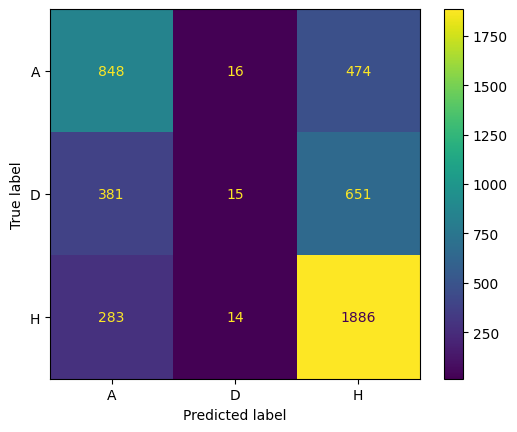

In [1304]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [1305]:
probs = lr_model.predict_proba(X_test_scaled)

print(lr_model.classes_)
print(probs[:10])

['A' 'D' 'H']
[[0.12907415 0.24845272 0.62247313]
 [0.50880854 0.22909144 0.26210002]
 [0.48004463 0.30396667 0.2159887 ]
 [0.26591181 0.32713721 0.40695098]
 [0.35689475 0.26895901 0.37414624]
 [0.16083763 0.25134658 0.58781579]
 [0.17924852 0.2953762  0.52537527]
 [0.20084552 0.32249341 0.47666107]
 [0.40580769 0.28013533 0.31405699]
 [0.07240247 0.17294225 0.75465528]]


In [1306]:
import seaborn as sns

In [1307]:
print(X_upcoming.shape)
print(scaler.feature_names_in_)


(72, 18)
['home_scored' 'home_conceded' 'home_win_rate' 'away_scored'
 'away_conceded' 'away_win_rate' 'neutral' 'tournament_weight'
 'h2h_home_wins' 'h2h_away_wins' 'h2h_draws' 'elo_home' 'elo_away'
 'elo_diff' 'home_draw_rate' 'away_draw_rate' 'home_goal_diff'
 'away_goal_diff']


In [1308]:
predictions

array(['H', 'H', 'H', 'H', 'A', 'A', 'A', 'A', 'H', 'A', 'H', 'A', 'H',
       'H', 'H', 'A', 'H', 'H', 'H', 'A', 'H', 'A', 'H', 'A', 'H', 'H',
       'H', 'H', 'H', 'A', 'H', 'H', 'H', 'A', 'H', 'H', 'H', 'A', 'H',
       'H', 'H', 'H', 'H', 'A', 'H', 'H', 'H', 'A', 'H', 'H', 'A', 'A',
       'H', 'H', 'H', 'A', 'A', 'A', 'H', 'A', 'H', 'A', 'A', 'A', 'A',
       'A', 'A', 'H', 'A', 'A', 'A', 'H'], dtype=object)

In [1309]:
probabilities= lr_model.predict_proba(X_upcoming_scaled)
upcoming_df = upcoming_df.reset_index(drop=True)
for i,row in upcoming_df.iterrows():
    away_prob=probabilities[i][0]*100
    draw_prob=probabilities[i][1]*100
    home_prob=probabilities[i][2]*100
    print(f"{row["home_team"]} vs {row["away_team"]}")
    print(f"{row["home_team"]} Win: {home_prob:.2f}%")
    print(f"{row["away_team"]} Win: {away_prob:.2f}%")
    print(f"Draw: {draw_prob:.2f}%")
    print("-"*40)



Mexico vs South Africa
Mexico Win: 82.86%
South Africa Win: 4.62%
Draw: 12.53%
----------------------------------------
South Korea vs Czech Republic
South Korea Win: 43.68%
Czech Republic Win: 35.34%
Draw: 20.98%
----------------------------------------
Canada vs Bosnia and Herzegovina
Canada Win: 78.23%
Bosnia and Herzegovina Win: 6.97%
Draw: 14.79%
----------------------------------------
United States vs Paraguay
United States Win: 51.80%
Paraguay Win: 28.20%
Draw: 19.99%
----------------------------------------
Qatar vs Switzerland
Qatar Win: 6.40%
Switzerland Win: 81.05%
Draw: 12.55%
----------------------------------------
Brazil vs Morocco
Brazil Win: 38.66%
Morocco Win: 39.87%
Draw: 21.47%
----------------------------------------
Haiti vs Scotland
Haiti Win: 22.23%
Scotland Win: 58.06%
Draw: 19.71%
----------------------------------------
Australia vs Turkey
Australia Win: 34.97%
Turkey Win: 43.24%
Draw: 21.79%
----------------------------------------
Sweden vs Tunisia
Sweden 

In [1310]:
actual_results = {
    # Matchday 1
    'Mexico vs South Africa':'H',
    'South Korea vs Czech Republic':'H',
    'Canada vs Bosnia and Herzegovina':'D',
    'United States vs Paraguay':'H',
    'Qatar vs Switzerland': 'D',
    'Brazil vs Morocco': 'D',
    'Haiti vs Scotland': 'A',
    'Australia vs Turkey': 'H',
    'Germany vs Curaçao': 'H',
    'Ivory Coast vs Ecuador': 'H',
    'Netherlands vs Japan': 'D',
    'Sweden vs Tunisia': 'H',
    'Belgium vs Egypt': 'D',
    'Iran vs New Zealand': 'D',
    'Spain vs Cape Verde': 'D',
    'Saudi Arabia vs Uruguay': 'D',
    'France vs Senegal': 'H',
    'Iraq vs Norway': 'A',
    'Argentina vs Algeria': 'H',
    'Austria vs Jordan': 'H',
    'Portugal vs DR Congo': 'D',
    'Uzbekistan vs Colombia': 'A',
    'England vs Croatia': 'H',
    'Ghana vs Panama': 'H',
    'Czech Republic vs South Africa': 'A',
    'Mexico vs South Korea': 'H',
    'Switzerland vs Bosnia and Herzegovina': 'H',
    'Canada vs Qatar': 'H',
    # Matchday 2
    'Scotland vs Morocco': 'A',
    'Brazil vs Haiti': 'H',
    'United States vs Australia': 'H',
    'Turkey vs Paraguay': 'A',
    'Germany vs Ivory Coast': 'H',
    'Ecuador vs Curaçao': 'D',
    'Netherlands vs Sweden': 'H',
    'Tunisia vs Japan': 'A',
    'Belgium vs Iran': 'D',
    'New Zealand vs Egypt': 'A',
    'Spain vs Saudi Arabia': 'H',
    'Uruguay vs Cape Verde': 'H',
    'France vs Iraq': 'H',
    'Norway vs Senegal': 'H',
    'Argentina vs Austria': 'H',
    'Jordan vs Algeria': 'A',
    'Portugal vs Uzbekistan': 'H',
    'Colombia vs DR Congo': 'H',
    'England vs Ghana': 'D',
    'Panama vs Croatia': 'A',
    'Mexico vs Czech Republic': 'H',
    'South Africa vs South Korea': 'H',
    'Canada vs Switzerland': 'H',
    'Bosnia and Herzegovina vs Qatar': 'H',
    # Matchday 3
    'Scotland vs Brazil': 'A',
    'Morocco vs Haiti': 'H',
    'United States vs Turkey': 'H',
    'Paraguay vs Australia': 'A',
    'Curaçao vs Ivory Coast': 'A',
    'Ecuador vs Germany': 'A',
    'Japan vs Sweden': 'H',
    'Tunisia vs Netherlands': 'A',
    'Egypt vs Iran': 'D',
    'New Zealand vs Belgium': 'A',
    'Cape Verde vs Saudi Arabia': 'D',
    'Uruguay vs Spain': 'A',
    'Norway vs France': 'A',
    'Senegal vs Iraq': 'H',
    'Algeria vs Austria': 'D',
    'Jordan vs Argentina': 'A',
    'Colombia vs Portugal': 'D',
    'DR Congo vs Uzbekistan': 'H',
    'Panama vs England': 'A',
    'Croatia vs Ghana': 'H',
}
correct=0
total=0
wrong_predictions=[]
correct_predictions=[]
def convert(result, row):
    if result == "H":
        return row["home_team"]
    elif result == "A":
        return row["away_team"]
    else:
        return "Draw"
for _,row in upcoming_df.iterrows():
    match_key=f"{row["home_team"]} vs {row["away_team"]}"
    actual=actual_results[match_key]
    predicted=row['predicted_result']
    if actual==predicted:
        correct+=1
        correct_predictions.append(f"{match_key}: prediction:{convert(predicted,row)},actual:{convert(actual,row)}")

    else:
        wrong_predictions.append(f"{match_key}: prediction:{convert(predicted,row)},actual:{convert(actual,row)}")
    total+=1


print(f"Correct: {correct}/{total}")
print(f"Accuracy: {round(correct/total*100, 2)}%")
print(f"\nCorrect:")
for w in correct_predictions:
    print(w)

Correct: 49/72
Accuracy: 68.06%

Correct:
Mexico vs South Africa: prediction:Mexico,actual:Mexico
South Korea vs Czech Republic: prediction:South Korea,actual:South Korea
United States vs Paraguay: prediction:United States,actual:United States
Haiti vs Scotland: prediction:Scotland,actual:Scotland
Sweden vs Tunisia: prediction:Sweden,actual:Sweden
Germany vs Curaçao: prediction:Germany,actual:Germany
Austria vs Jordan: prediction:Austria,actual:Austria
Argentina vs Algeria: prediction:Argentina,actual:Argentina
France vs Senegal: prediction:France,actual:France
Iraq vs Norway: prediction:Norway,actual:Norway
Uzbekistan vs Colombia: prediction:Colombia,actual:Colombia
England vs Croatia: prediction:England,actual:England
Mexico vs South Korea: prediction:Mexico,actual:Mexico
Switzerland vs Bosnia and Herzegovina: prediction:Switzerland,actual:Switzerland
Canada vs Qatar: prediction:Canada,actual:Canada
Scotland vs Morocco: prediction:Morocco,actual:Morocco
Brazil vs Haiti: prediction:Br

In [1311]:
upcoming_df.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,...,away_win_rate,away_draw_rate,h2h_home_wins,h2h_away_wins,h2h_draws,tournament_weight,elo_home,elo_away,elo_diff,predicted_result
67,2026-06-27,Algeria,Austria,NaN,NaN,FIFA World Cup,Kansas City,United States,1,D,...,0.8,0.1,0,0,0,5,1345.704740,1335.257349,10.447391,H
68,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,1,D,...,0.8,0.1,0,0,0,5,1195.264318,1555.332610,-360.068292,A
69,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,1,D,...,0.7,0.2,0,0,0,5,1442.104926,1450.506595,-8.401669,A
70,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,1,D,...,0.4,0.3,0,0,0,5,1207.118540,1265.409504,-58.290963,A
71,2026-06-27,Croatia,Ghana,NaN,NaN,FIFA World Cup,Philadelphia,United States,1,D,...,0.3,0.2,0,0,0,5,1366.774692,1072.792228,293.982464,H


In [1312]:
import matplotlib.pyplot as plt
# import numpy as np

# # Get the highest probability for each match
# upcoming_df['max_prob'] = probabilities.max(axis=1) * 100
# upcoming_df['predicted_team'] = upcoming_df.apply(
#     lambda row: row['home_team'] if row['predicted_result'] == 'H' 
#     else (row['away_team'] if row['predicted_result'] == 'A' 
#     else 'Draw'), axis=1
# )
# upcoming_df['match'] = upcoming_df['home_team'] + ' vs ' + upcoming_df['away_team']

# # Top 15 most confident
# top15 = upcoming_df.nlargest(15, 'max_prob')

# plt.figure(figsize=(12, 8))
# bars = plt.barh(top15['match'], top15['max_prob'], color='steelblue')
# plt.xlabel('Confidence %')
# plt.title('Top 15 Most Confident Predictions — FIFA World Cup 2026')
# plt.xlim(0, 100)

# # Add percentage labels
# for bar, val in zip(bars, top15['max_prob']):
#     plt.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
#              f'{val:.1f}%', va='center', fontsize=9)



In [1313]:


# correct = correct
# wrong = total - correct

# plt.figure(figsize=(6,5))

# bars = plt.bar(
#     ['Correct', 'Wrong'],
#     [correct, wrong],
#     color=['blue', 'red']
# )

# plt.title("Prediction Accuracy Breakdown", fontsize=15)
# plt.xlabel("Prediction")
# plt.ylabel("Number of Matches")

# for bar in bars:
#     height = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2,
#              height + 0.3,
#              int(height),
#              ha='center',
#              fontsize=11)

# plt.grid(axis='y', linestyle='--', alpha=0.4)

# plt.tight_layout()
# plt.show()

In [1314]:
# plt.figure(figsize=(6,6))

# plt.pie(
#     [correct, wrong],
#     labels=['Correct', 'Wrong'],
#     autopct='%1.1f%%',
#     colors=['skyblue', 'gold'],
#     startangle=90
# )

# plt.title("Prediction Accuracy")

# plt.show()

In [1315]:
# wc_teams=pd.unique(
#     pd.concat(
#         [
#             upcoming_df['home_team'],
#             upcoming_df['away_team']
#         ]
#     )
# )
    
# elo_df = pd.DataFrame(
#     list(final_elo.items()),
#     columns=["Team", "Elo"]
# )
# wc_elo=elo_df[elo_df["Team"].isin(wc_teams)].sort_values("Elo",ascending=False)
# wc_elo.reset_index(drop=True)


In [1316]:


# plt.figure(figsize=(12,12))
country_colors = {
    "Algeria": "#006233",
    "Argentina": "#75AADB",
    "Australia": "#012169",
    "Austria": "#ED2939",
    "Belgium": "#FFD90C",
    "Bosnia and Herzegovina": "#002F6C",
    "Brazil": "#009C3B",
    "Canada": "#D80621",
    "Cape Verde": "#003893",
    "Colombia": "#FCD116",
    "Croatia": "#FF0000",
    "Curaçao": "#0057B8",
    "Czech Republic": "#11457E",
    "DR Congo": "#007FFF",
    "Ecuador": "#FFD100",
    "Egypt": "#CE1126",
    "England": "#C8102E",
    "France": "#0055A4",
    "Germany": "#000000",
    "Ghana": "#CE1126",
    # "Haiti": "#00209F",
    "Iran": "#239F40",
    "Iraq": "#007A3D",
    "Ivory Coast": "#F77F00",
    "Japan": "#BC002D",
    "Jordan": "#007A3D",
    "Mexico": "#006847",
    "Morocco": "#C1272D",
    "Netherlands": "#FF6600",
    "New Zealand": "#00247D",
    "Norway": "#BA0C2F",
    "Panama": "#D21034",
    "Paraguay": "#D52B1E",
    "Portugal": "#046A38",
    "Qatar": "#8A1538",
    "Saudi Arabia": "#006C35",
    "Scotland": "#0065BD",
    "Senegal": "#00853F",
    "South Africa": "#007A4D",
    "South Korea": "#003478",
    "Spain": "#AA151B",
    "Sweden": "#006AA7",
    "Switzerland": "#D52B1E",
    "Tunisia": "#E70013",
    "Turkey": "#E30A17",
    "United States": "#3C3B6E",
    "Uruguay": "#6CB4EE",
    "Uzbekistan": "#0099B5"
}
# colors = [country_colors[team] for team in wc_elo["Team"]]

# bars = plt.barh(
#     wc_elo["Team"],
#     wc_elo["Elo"],
#     color=colors
# )

# plt.gca().invert_yaxis()

# plt.title("2026 FIFA World Cup Teams by Elo Rating", fontsize=16)
# plt.xlabel("Elo Rating", fontsize=12)
# plt.ylabel("Team", fontsize=12)

# plt.grid(axis='x', linestyle='--', alpha=0.4)
# for bar in bars:
#     width = bar.get_width()

#     plt.text(
#         width + 2,                           # x-position (slightly after the bar)
#         bar.get_y() + bar.get_height()/2,    # y-position (middle of the bar)
#         f"{width:.0f}",                      # Elo value, rounded to nearest integer
#         va="center",
#         fontsize=9
#     )
# plt.tight_layout()

# # plt.show()

In [1317]:
probabilities = lr_model.predict_proba(X_upcoming_scaled)

upcoming_df["away_win_prob"] = probabilities[:, 0] * 100
upcoming_df["draw_prob"] = probabilities[:, 1] * 100
upcoming_df["home_win_prob"] = probabilities[:, 2] * 100

In [1318]:
arg_matches=upcoming_df[(upcoming_df['home_team']=="Argentina") | (upcoming_df["away_team"]=="Argentina")]
arg_matches[
    [
        "home_team",
        "away_team",
        "predicted_result",
        "home_win_prob",
        "draw_prob",
        "away_win_prob"
    ]
]

,home_team,away_team,predicted_result,home_win_prob,draw_prob,away_win_prob
17,Argentina,Algeria,H,69.110038,17.860437,13.029524
42,Argentina,Austria,H,70.911756,17.077940,12.010304
68,Jordan,Argentina,A,3.169810,9.640248,87.189942


In [1319]:
probabilities = lr_model.predict_proba(X_upcoming_scaled)

upcoming_df["away_win_prob"] = probabilities[:, 0] * 100
upcoming_df["draw_prob"] = probabilities[:, 1] * 100
upcoming_df["home_win_prob"] = probabilities[:, 2] * 100

In [1320]:
def get_team_matches(team):
    team_matches=upcoming_df[(upcoming_df['home_team']==team) | (upcoming_df["away_team"]==team)]
    return team_matches[

    [
        "home_team",
        "away_team",
        "predicted_result",
        "home_win_prob",
        "draw_prob",
        "away_win_prob"
    ]
]
    
get_team_matches("Spain")

,home_team,away_team,predicted_result,home_win_prob,draw_prob,away_win_prob
14,Spain,Cape Verde,H,89.364511,7.783806,2.851683
38,Spain,Saudi Arabia,H,86.701827,9.239132,4.059040
62,Uruguay,Spain,A,11.408830,18.579814,70.011356


In [1321]:


def plot_team_predictions(team_name):

    team_matches = get_team_matches(team_name)

    for _, row in team_matches.iterrows():

        # Labels
        labels = [
            f"{row['home_team']} Win",
            "Draw",
            f"{row['away_team']} Win"
        ]

        # Probabilities
        probs = [
            row["home_win_prob"],
            row["draw_prob"],
            row["away_win_prob"]
        ]

        # Colors
        colors = [
        country_colors[row["home_team"]],
        "gray",
        country_colors[row["away_team"]]
        ]

        plt.figure(figsize=(8,3.5))

        bars = plt.barh(
            labels,
            probs,
            color=colors
        )

        plt.xlim(0,100)

        plt.xlabel("Probability (%)")
        plt.title(f"{row['home_team']} vs {row['away_team']}")

        # Display probability values
        for bar in bars:

            width = bar.get_width()

            plt.text(
                width + 1,
                bar.get_y() + bar.get_height()/2,
                f"{width:.1f}%",
                va="center",
                fontsize=10,
                fontweight="bold"
            )

        plt.grid(axis="x", linestyle="--", alpha=0.4)

        plt.tight_layout()
        plt.show()

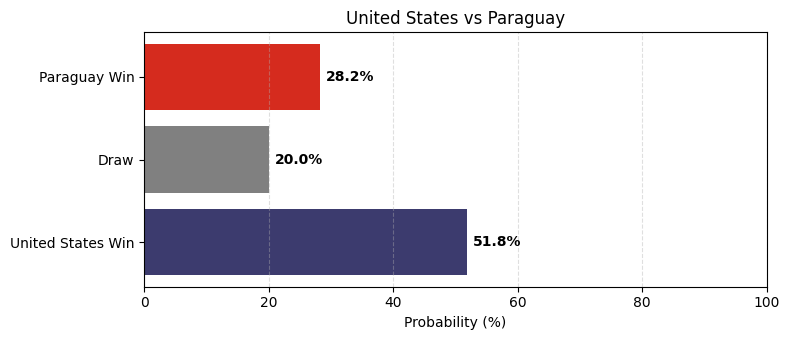

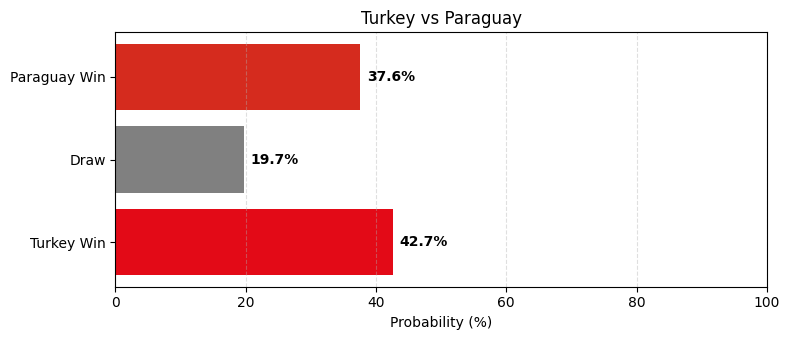

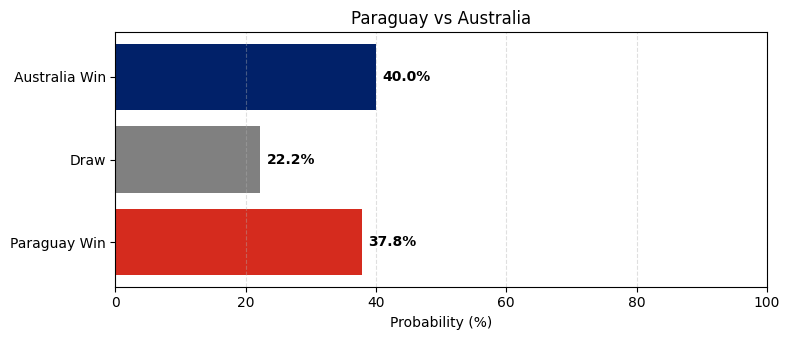

In [1322]:
plot_team_predictions("Paraguay")

In [1323]:
r32_fixtures = pd.DataFrame([
    {'home_team': 'South Africa', 'away_team': 'Canada', 'date': '2026-06-28', 'neutral': 1},
    {'home_team': 'Brazil', 'away_team': 'Japan', 'date': '2026-06-29', 'neutral': 1},
    {'home_team': 'Germany', 'away_team': 'Paraguay', 'date': '2026-06-29', 'neutral': 1},
    {'home_team': 'Netherlands', 'away_team': 'Morocco', 'date': '2026-06-30', 'neutral': 1},
    {'home_team': 'Ivory Coast', 'away_team': 'Norway', 'date': '2026-06-30', 'neutral': 1},
    {'home_team': 'France', 'away_team': 'Sweden', 'date': '2026-06-30', 'neutral': 1},
    {'home_team': 'Mexico', 'away_team': 'Ecuador', 'date': '2026-07-01', 'neutral': 0},
    {'home_team': 'England', 'away_team': 'DR Congo', 'date': '2026-07-01', 'neutral': 1},
    {'home_team': 'Belgium', 'away_team': 'Senegal', 'date': '2026-07-02', 'neutral': 1},
    {'home_team': 'United States', 'away_team': 'Bosnia and Herzegovina', 'date': '2026-07-02', 'neutral': 0},
    {'home_team': 'Spain', 'away_team': 'Austria', 'date': '2026-07-03', 'neutral': 1},
    {'home_team': 'Portugal', 'away_team': 'Croatia', 'date': '2026-07-03', 'neutral': 1},
    {'home_team': 'Switzerland', 'away_team': 'Algeria', 'date': '2026-07-03', 'neutral': 1},
    {'home_team': 'Australia', 'away_team': 'Egypt', 'date': '2026-07-03', 'neutral': 1},
    {'home_team': 'Argentina', 'away_team': 'Cape Verde', 'date': '2026-07-03', 'neutral': 1},
    {'home_team': 'Colombia', 'away_team': 'Ghana', 'date': '2026-07-03', 'neutral': 1},
])

r32_fixtures['date'] = pd.to_datetime(r32_fixtures['date'])
r32_fixtures['tournament'] = 'FIFA World Cup'
r32_fixtures['tournament_weight'] = 5

print(r32_fixtures.shape)
print("R32 fixtures loaded!")
r32_fixtures

(16, 6)
R32 fixtures loaded!


,home_team,away_team,date,neutral,tournament,tournament_weight
0,South Africa,Canada,2026-06-28,1,FIFA World Cup,5
1,Brazil,Japan,2026-06-29,1,FIFA World Cup,5
2,Germany,Paraguay,2026-06-29,1,FIFA World Cup,5
3,Netherlands,Morocco,2026-06-30,1,FIFA World Cup,5
4,Ivory Coast,Norway,2026-06-30,1,FIFA World Cup,5
5,France,Sweden,2026-06-30,1,FIFA World Cup,5
6,Mexico,Ecuador,2026-07-01,0,FIFA World Cup,5
7,England,DR Congo,2026-07-01,1,FIFA World Cup,5
8,Belgium,Senegal,2026-07-02,1,FIFA World Cup,5
9,United States,Bosnia and Herzegovina,2026-07-02,0,FIFA World Cup,5


In [1324]:
# # Get all 2026 WC group stage matches from upcoming_df
# upcoming_matches = set(
#     upcoming_df['home_team'] + ' vs ' + upcoming_df['away_team']
# )
# print(f"We have: {len(upcoming_matches)} matches")
# print("\nOur matches:")
# for m in sorted(upcoming_matches):
#     print(m)

In [1325]:
# # Find 2026 World Cup matches that already have scores (in historical_df)
# wc_2026_played = historical_df[
#     (historical_df['tournament'] == 'FIFA World Cup') &
#     (historical_df['date'] >= '2026-06-01')
# ]

# print(f"WC 2026 matches already in historical_df: {len(wc_2026_played)}")
# print(wc_2026_played[['date', 'home_team', 'away_team', 'home_score', 'away_score']].to_string())

In [1326]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost needs numeric labels, not H/A/D strings
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_scaled, y_train_encoded)
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_accuracy = (xgb_pred == y_test_encoded).mean() * 100
print(f"XGBoost: {round(xgb_accuracy, 2)}%")
xgb_pred_labels = le.inverse_transform(xgb_pred)

print(classification_report(y_test, xgb_pred_labels))

XGBoost: 59.94%
              precision    recall  f1-score   support

           A       0.56      0.64      0.59      1338
           D       0.35      0.02      0.03      1047
           H       0.63      0.85      0.72      2183

    accuracy                           0.60      4568
   macro avg       0.51      0.50      0.45      4568
weighted avg       0.54      0.60      0.53      4568



In [1327]:
actual_scores = {

    # ---------------- GROUP A ----------------
    'Mexico vs South Africa': ('2026-06-11', 'H', 2, 0, 0),
    'South Korea vs Czech Republic': ('2026-06-11', 'H', 2, 1, 1),

    # ---------------- GROUP B ----------------
    'Canada vs Bosnia and Herzegovina': ('2026-06-12', 'D', 1, 1, 0),
    'United States vs Paraguay': ('2026-06-12', 'H', 4, 1, 0),

    'Qatar vs Switzerland': ('2026-06-13', 'D', 1, 1, 1),
    'Brazil vs Morocco': ('2026-06-13', 'D', 1, 1, 1),
    'Haiti vs Scotland': ('2026-06-13', 'A', 0, 1, 1),
    'Australia vs Turkey': ('2026-06-13', 'H', 2, 0, 1),

    'Germany vs Curaçao': ('2026-06-14', 'H', 7, 0, 1),
    'Ivory Coast vs Ecuador': ('2026-06-14', 'H', 2, 1, 1),
    'Netherlands vs Japan': ('2026-06-14', 'D', 2, 2, 1),
    'Sweden vs Tunisia': ('2026-06-14', 'H', 5, 1, 1),

    'Belgium vs Egypt': ('2026-06-14', 'D', 1, 1, 1),
    'Iran vs New Zealand': ('2026-06-14', 'D', 2, 2, 1),

    'Spain vs Cape Verde': ('2026-06-14', 'D', 0, 0, 1),
    'Saudi Arabia vs Uruguay': ('2026-06-14', 'D', 1, 1, 1),

    'France vs Senegal': ('2026-06-14', 'H', 3, 1, 1),
    'Iraq vs Norway': ('2026-06-14', 'A', 1, 4, 1),

    'Argentina vs Algeria': ('2026-06-14', 'H', 3, 0, 1),
    'Austria vs Jordan': ('2026-06-14', 'H', 3, 1, 1),

    'Portugal vs DR Congo': ('2026-06-14', 'D', 1, 1, 1),
    'Uzbekistan vs Colombia': ('2026-06-14', 'A', 1, 3, 1),

    'England vs Croatia': ('2026-06-14', 'H', 4, 2, 1),
    'Ghana vs Panama': ('2026-06-14', 'H', 1, 0, 1),
        # ---------------- MATCHDAY 2 ----------------

    # Group A
    'Czech Republic vs South Africa': ('2026-06-18', 'D', 1, 1, 1),
    'Mexico vs South Korea': ('2026-06-18', 'H', 1, 0, 0),

    # Group B
    'Switzerland vs Bosnia and Herzegovina': ('2026-06-18', 'H', 4, 1, 1),
    'Canada vs Qatar': ('2026-06-18', 'H', 3, 0, 0),

    # Group C
    'Scotland vs Morocco': ('2026-06-19', 'A', 0, 2, 1),
    'Brazil vs Haiti': ('2026-06-19', 'H', 3, 0, 1),

    # Group D
    'United States vs Australia': ('2026-06-19', 'H', 3, 1, 0),
    'Turkey vs Paraguay': ('2026-06-19', 'A', 0, 1, 1),

    # Group E
    'Germany vs Ivory Coast': ('2026-06-20', 'H', 2, 0, 1),
    'Ecuador vs Curaçao': ('2026-06-20', 'D', 1, 1, 1),

    # Group F
    'Netherlands vs Sweden': ('2026-06-20', 'H', 5, 1, 1),
    'Tunisia vs Japan': ('2026-06-20', 'A', 0, 4, 1),

    # Group G
    'Belgium vs Iran': ('2026-06-20', 'D', 0, 0, 1),
    'New Zealand vs Egypt': ('2026-06-20', 'A', 0, 3, 1),

    # Group H
    'Spain vs Saudi Arabia': ('2026-06-20', 'H', 4, 0, 1),
    'Uruguay vs Cape Verde': ('2026-06-20', 'H', 2, 0, 1),

    # Group I
    'France vs Iraq': ('2026-06-20', 'H', 3, 0, 1),
    'Norway vs Senegal': ('2026-06-20', 'H', 3, 2, 1),

    # Group J
    'Argentina vs Austria': ('2026-06-20', 'H', 2, 0, 1),
    'Jordan vs Algeria': ('2026-06-20', 'A', 1, 2, 1),

    # Group K
    'Portugal vs Uzbekistan': ('2026-06-20', 'H', 5, 0, 1),
    'Colombia vs DR Congo': ('2026-06-20', 'H', 2, 0, 1),

    # Group L
    'England vs Ghana': ('2026-06-20', 'D', 0, 0, 1),
    'Panama vs Croatia': ('2026-06-20', 'A', 0, 1, 1),
        # ---------------- MATCHDAY 3 ----------------

    # Group A
    'Mexico vs Czech Republic': ('2026-06-24', 'H', 3, 0, 0),
    'South Africa vs South Korea': ('2026-06-24', 'H', 1, 0, 1),

    # Group B
    'Canada vs Switzerland': ('2026-06-24', 'H', 2, 1, 0),
    'Bosnia and Herzegovina vs Qatar': ('2026-06-24', 'H', 2, 0, 1),

    # Group C
    'Scotland vs Brazil': ('2026-06-25', 'A', 0, 2, 1),
    'Morocco vs Haiti': ('2026-06-25', 'H', 3, 0, 1),

    # Group D
    'United States vs Turkey': ('2026-06-25', 'H', 2, 1, 0),
    'Paraguay vs Australia': ('2026-06-25', 'A', 0, 1, 1),

    # Group E
    'Curaçao vs Ivory Coast': ('2026-06-26', 'A', 0, 2, 1),
    'Ecuador vs Germany': ('2026-06-26', 'A', 2, 3, 1),

    # Group F
    'Japan vs Sweden': ('2026-06-26', 'H', 2, 0, 1),
    'Tunisia vs Netherlands': ('2026-06-26', 'A', 0, 3, 1),

    # Group G
    'Egypt vs Iran': ('2026-06-26', 'D', 1, 1, 1),
    'New Zealand vs Belgium': ('2026-06-26', 'A', 0, 5, 1),

    # Group H
    'Cape Verde vs Saudi Arabia': ('2026-06-26', 'A', 0, 2, 1),
    'Uruguay vs Spain': ('2026-06-26', 'A', 0, 2, 1),

    # Group I
    'Norway vs France': ('2026-06-26', 'A', 1, 4, 1),
    'Senegal vs Iraq': ('2026-06-26', 'H', 5, 0, 1),

    # Group J
    'Jordan vs Argentina': ('2026-06-27', 'A', 1, 3, 1),
    'Algeria vs Austria': ('2026-06-27', 'D', 3, 3, 1),

    # Group K
    'Colombia vs Portugal': ('2026-06-27', 'D', 0, 0, 1),
    'DR Congo vs Uzbekistan': ('2026-06-27', 'H', 2, 1, 1),

    # Group L
    'Panama vs England': ('2026-06-27', 'A', 0, 2, 1),
    'Croatia vs Ghana': ('2026-06-27', 'H', 2, 1, 1),
}

# Build group stage dataframe
gs_rows = []

for match, values in actual_scores.items():

    date, result, hs, as_, neutral = values

    home, away = match.split(" vs ")

    gs_rows.append({
        "date": pd.to_datetime(date),
        "home_team": home,
        "away_team": away,
        "home_score": hs,
        "away_score": as_,
        "result": result,
        "tournament": "FIFA World Cup",
        "neutral": neutral
    })

wc_group_stage = (
    pd.DataFrame(gs_rows)
      .sort_values("date")
      .reset_index(drop=True)
)

wc_group_stage

,date,home_team,away_team,home_score,away_score,result,tournament,neutral
0,2026-06-11,Mexico,South Africa,2,0,H,FIFA World Cup,0
1,2026-06-11,South Korea,Czech Republic,2,1,H,FIFA World Cup,1
2,2026-06-12,Canada,Bosnia and Herzegovina,1,1,D,FIFA World Cup,0
3,2026-06-12,United States,Paraguay,4,1,H,FIFA World Cup,0
4,2026-06-13,Qatar,Switzerland,1,1,D,FIFA World Cup,1
...,...,...,...,...,...,...,...,...
67,2026-06-27,Jordan,Argentina,1,3,A,FIFA World Cup,1
68,2026-06-27,Algeria,Austria,3,3,D,FIFA World Cup,1
69,2026-06-27,Colombia,Portugal,0,0,D,FIFA World Cup,1
70,2026-06-27,DR Congo,Uzbekistan,2,1,H,FIFA World Cup,1


In [1328]:
# Combine historical + group stage for updated Elo
elo_data = pd.concat([historical_df, wc_group_stage], ignore_index=True)
elo_data = elo_data.sort_values('date').reset_index(drop=True)

# Recalculate Elo including group stage results
elo_data, updated_elo = calculate_elo(elo_data)

print("Top 10 after group stage:")
sorted_elo = sorted(updated_elo.items(), key=lambda x: x[1], reverse=True)
for team, rating in sorted_elo[:10]:
    print(f"{team}: {round(rating)}")
elo_data.tail(12)

Top 10 after group stage:
Argentina: 1579
Spain: 1529
France: 1511
Germany: 1466
Brazil: 1463
Colombia: 1460
England: 1451
Japan: 1451
Portugal: 1449
Morocco: 1446


,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,...,away_goal_diff,away_win_rate,away_draw_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
25403,NaN,2026-06-26,Ecuador,Germany,2.0,3.0,FIFA World Cup,1,A,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1361.748333,1454.563792,NaN
25404,NaN,2026-06-26,Norway,France,1.0,4.0,FIFA World Cup,1,A,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1389.815373,1494.183265,NaN
25405,NaN,2026-06-26,Senegal,Iraq,5.0,0.0,FIFA World Cup,1,H,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1292.086849,1179.723451,NaN
25406,NaN,2026-06-26,Cape Verde,Saudi Arabia,0.0,2.0,FIFA World Cup,1,A,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1134.332048,1175.470303,NaN
25407,NaN,2026-06-26,Uruguay,Spain,0.0,2.0,FIFA World Cup,1,A,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1342.483163,1518.425505,NaN
25408,NaN,2026-06-26,Egypt,Iran,1.0,1.0,FIFA World Cup,1,D,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1280.925597,1331.476425,NaN
25409,NaN,2026-06-27,Colombia,Portugal,0.0,0.0,FIFA World Cup,1,D,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1461.095201,1448.500973,NaN
25410,NaN,2026-06-27,Algeria,Austria,3.0,3.0,FIFA World Cup,1,D,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1344.074111,1338.765917,NaN
25411,NaN,2026-06-27,DR Congo,Uzbekistan,2.0,1.0,FIFA World Cup,1,H,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1213.262667,1242.286470,NaN
25412,NaN,2026-06-27,Panama,England,0.0,2.0,FIFA World Cup,1,A,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1191.845402,1443.259852,NaN


In [1329]:
r32_scores = {

    'South Africa vs Canada': ('2026-06-28', 'A', 0, 1, 1),

    'Brazil vs Japan': ('2026-06-29', 'H', 2, 1, 1),
    'Germany vs Paraguay': ('2026-06-29', 'A', 1, 1, 1),
    'Netherlands vs Morocco': ('2026-06-29', 'A', 1, 1, 1),

    'Ivory Coast vs Norway': ('2026-06-30', 'A', 1, 2, 1),
    'France vs Sweden': ('2026-06-30', 'H', 3, 0, 1),

    'Mexico vs Ecuador': ('2026-07-01', 'H', 2, 0, 0),
    'England vs DR Congo': ('2026-07-01', 'H', 2, 1, 1),

    'Belgium vs Senegal': ('2026-07-02', 'H', 3, 2, 1),
    'United States vs Bosnia and Herzegovina': ('2026-07-02', 'H', 2, 0, 0),

    'Spain vs Austria': ('2026-07-03', 'H', 3, 0, 1),
    'Portugal vs Croatia': ('2026-07-03', 'H', 2, 1, 1),
    'Switzerland vs Algeria': ('2026-07-03', 'H', 2, 1, 1),
    'Australia vs Egypt': ('2026-07-03', 'A', 1, 1, 1),

    'Argentina vs Cape Verde': ('2026-07-03', 'H', 3, 2, 1),
    'Colombia vs Ghana': ('2026-07-03', 'H', 1, 0, 1),
}
r32_rows = []

for match, values in r32_scores.items():

    date, result, hs, as_, neutral = values

    home, away = match.split(" vs ")

    r32_rows.append({
        "date": pd.to_datetime(date),
        "home_team": home,
        "away_team": away,
        "home_score": hs,
        "away_score": as_,
        "result": result,
        "tournament": "FIFA World Cup",
        "neutral": neutral
    })

wc_r32 = (
    pd.DataFrame(r32_rows)
      .sort_values("date")
      .reset_index(drop=True)
)

print(wc_r32)

         date      home_team               away_team  home_score  away_score  \
0  2026-06-28   South Africa                  Canada           0           1   
1  2026-06-29         Brazil                   Japan           2           1   
2  2026-06-29        Germany                Paraguay           1           1   
3  2026-06-29    Netherlands                 Morocco           1           1   
4  2026-06-30    Ivory Coast                  Norway           1           2   
5  2026-06-30         France                  Sweden           3           0   
6  2026-07-01         Mexico                 Ecuador           2           0   
7  2026-07-01        England                DR Congo           2           1   
8  2026-07-02        Belgium                 Senegal           3           2   
9  2026-07-02  United States  Bosnia and Herzegovina           2           0   
10 2026-07-03          Spain                 Austria           3           0   
11 2026-07-03       Portugal            

In [1330]:
elo_data = pd.concat(
    [elo_data, wc_r32],
    ignore_index=True
)

elo_data = (
    elo_data
    .sort_values("date")
    .reset_index(drop=True)
)

print(elo_data.shape)
elo_data.tail()

(25431, 27)


,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,...,away_goal_diff,away_win_rate,away_draw_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
25426,NaN,2026-07-03,Switzerland,Algeria,2.0,1.0,FIFA World Cup,1,H,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25427,NaN,2026-07-03,Argentina,Cape Verde,3.0,2.0,FIFA World Cup,1,H,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25428,NaN,2026-07-03,Spain,Austria,3.0,0.0,FIFA World Cup,1,H,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25429,NaN,2026-07-03,Portugal,Croatia,2.0,1.0,FIFA World Cup,1,H,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25430,NaN,2026-07-03,Colombia,Ghana,1.0,0.0,FIFA World Cup,1,H,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1331]:
elo_data, final_elo = calculate_elo(elo_data)

elo_data["elo_diff"] = elo_data["elo_home"] - elo_data["elo_away"]

print("Updated Elo after Round of 32!")
print(final_elo["Argentina"])
print(final_elo["Brazil"])
print(final_elo["Spain"])

Updated Elo after Round of 32!
1580.9250705192212
1478.4377897660686
1541.130003421147


In [1332]:
elo_data[elo_data["home_scored"].isna()].shape

(88, 27)

In [1333]:
mask = elo_data["home_scored"].isna() # checks if there any null values

for idx in elo_data[mask].index:

    row = elo_data.loc[idx]

    hs, hc, hgd, hw, hd = get_team_form(
        row["home_team"],
        row["date"],
        elo_data.iloc[:idx]
    )

    as_, ac, agd, aw, ad = get_team_form(
        row["away_team"],
        row["date"],
        elo_data.iloc[:idx]
    )

    elo_data.loc[idx, "home_scored"] = hs
    elo_data.loc[idx, "home_conceded"] = hc
    elo_data.loc[idx, "home_goal_diff"] = hgd
    elo_data.loc[idx, "home_win_rate"] = hw
    elo_data.loc[idx, "home_draw_rate"] = hd

    elo_data.loc[idx, "away_scored"] = as_
    elo_data.loc[idx, "away_conceded"] = ac
    elo_data.loc[idx, "away_goal_diff"] = agd
    elo_data.loc[idx, "away_win_rate"] = aw
    elo_data.loc[idx, "away_draw_rate"] = ad

In [1334]:
mask = elo_data["h2h_home_wins"].isna()

for idx in elo_data[mask].index:

    row = elo_data.loc[idx]

    # Only matches played BEFORE this match
    past_matches = elo_data[elo_data["date"] < row["date"]]

    h2hw, h2haw, h2hd = get_h2h(
        row["home_team"],
        row["away_team"],
        row["date"],
        past_matches
    )

    elo_data.loc[idx, "h2h_home_wins"] = h2hw
    elo_data.loc[idx, "h2h_away_wins"] = h2haw
    elo_data.loc[idx, "h2h_draws"] = h2hd

# Tournament weight (run once)
elo_data["tournament_weight"] = (
    elo_data["tournament"]
    .map(tournament_weight)
    .fillna(2)
)

# Elo difference
elo_data["elo_diff"] = elo_data["elo_home"] - elo_data["elo_away"]
elo_data[features].isna().sum()

home_scored          0
home_conceded        0
home_win_rate        0
away_scored          0
away_conceded        0
away_win_rate        0
neutral              0
tournament_weight    0
h2h_home_wins        0
h2h_away_wins        0
h2h_draws            0
elo_home             0
elo_away             0
elo_diff             0
home_draw_rate       0
away_draw_rate       0
home_goal_diff       0
away_goal_diff       0
dtype: int64

In [1335]:
r16_fixtures = pd.DataFrame([
    {"home_team":"Canada",         "away_team":"Morocco",   "date":"2026-07-04", "neutral":1},
    {"home_team":"Paraguay",       "away_team":"France",    "date":"2026-07-04", "neutral":1},

    {"home_team":"Brazil",         "away_team":"Norway",    "date":"2026-07-05", "neutral":1},
    {"home_team":"Mexico",         "away_team":"England",   "date":"2026-07-05", "neutral":0},

    {"home_team":"Portugal",       "away_team":"Spain",     "date":"2026-07-06", "neutral":1},
    {"home_team":"United States",  "away_team":"Belgium",   "date":"2026-07-06", "neutral":0},

    {"home_team":"Argentina",      "away_team":"Egypt",     "date":"2026-07-07", "neutral":1},
    {"home_team":"Switzerland",    "away_team":"Colombia",  "date":"2026-07-07", "neutral":1},
])

r16_fixtures["date"] = pd.to_datetime(r16_fixtures["date"])
r16_fixtures["tournament"] = "FIFA World Cup"
r16_fixtures["tournament_weight"] = 5

r16_fixtures

,home_team,away_team,date,neutral,tournament,tournament_weight
0,Canada,Morocco,2026-07-04,1,FIFA World Cup,5
1,Paraguay,France,2026-07-04,1,FIFA World Cup,5
2,Brazil,Norway,2026-07-05,1,FIFA World Cup,5
3,Mexico,England,2026-07-05,0,FIFA World Cup,5
4,Portugal,Spain,2026-07-06,1,FIFA World Cup,5
5,United States,Belgium,2026-07-06,0,FIFA World Cup,5
6,Argentina,Egypt,2026-07-07,1,FIFA World Cup,5
7,Switzerland,Colombia,2026-07-07,1,FIFA World Cup,5


In [1336]:
home_scored = []
home_conceded = []
home_goal_diff = []
home_win_rate = []
home_draw_rate = []

away_scored = []
away_conceded = []
away_goal_diff = []
away_win_rate = []
away_draw_rate = []

h2h_home_wins = []
h2h_away_wins = []
h2h_draws = []

for _, row in r16_fixtures.iterrows():

    hs, hc, hgd, hw, hd = get_team_form(
        row["home_team"],
        row["date"],
        elo_data
    )

    as_, ac, agd, aw, ad = get_team_form(
        row["away_team"],
        row["date"],
        elo_data
    )

    h2hw, h2haw, h2hd = get_h2h(
        row["home_team"],
        row["away_team"],
        row["date"],
        elo_data
    )

    home_scored.append(hs)
    home_conceded.append(hc)
    home_goal_diff.append(hgd)
    home_win_rate.append(hw)
    home_draw_rate.append(hd)

    away_scored.append(as_)
    away_conceded.append(ac)
    away_goal_diff.append(agd)
    away_win_rate.append(aw)
    away_draw_rate.append(ad)

    h2h_home_wins.append(h2hw)
    h2h_away_wins.append(h2haw)
    h2h_draws.append(h2hd)

In [1337]:
r16_fixtures["home_scored"] = home_scored
r16_fixtures["home_conceded"] = home_conceded
r16_fixtures["home_goal_diff"] = home_goal_diff
r16_fixtures["home_win_rate"] = home_win_rate
r16_fixtures["home_draw_rate"] = home_draw_rate

r16_fixtures["away_scored"] = away_scored
r16_fixtures["away_conceded"] = away_conceded
r16_fixtures["away_goal_diff"] = away_goal_diff
r16_fixtures["away_win_rate"] = away_win_rate
r16_fixtures["away_draw_rate"] = away_draw_rate

r16_fixtures["h2h_home_wins"] = h2h_home_wins
r16_fixtures["h2h_away_wins"] = h2h_away_wins
r16_fixtures["h2h_draws"] = h2h_draws

r16_fixtures["neutral"] = r16_fixtures["neutral"].astype(int)
r16_fixtures["tournament_weight"] = 5

# IMPORTANT: use updated Elo after the group stage
r16_fixtures["elo_home"] = r16_fixtures["home_team"].map(updated_elo).fillna(1000)
r16_fixtures["elo_away"] = r16_fixtures["away_team"].map(updated_elo).fillna(1000)
r16_fixtures["elo_diff"] = (
    r16_fixtures["elo_home"] - r16_fixtures["elo_away"]
)

r16_fixtures.head()

,home_team,away_team,date,neutral,tournament,tournament_weight,home_scored,home_conceded,home_goal_diff,home_win_rate,...,away_conceded,away_goal_diff,away_win_rate,away_draw_rate,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
0,Canada,Morocco,2026-07-04,1,FIFA World Cup,5,1.4,0.5,0.9,0.5,...,0.5,1.8,0.7,0.3,0,1,0,1340.363916,1445.516472,-105.152556
1,Paraguay,France,2026-07-04,1,FIFA World Cup,5,1.2,1.3,-0.1,0.5,...,0.8,2.1,0.9,0.0,0,0,0,1283.928731,1511.183089,-227.254358
2,Brazil,Norway,2026-07-05,1,FIFA World Cup,5,2.3,0.9,1.4,0.7,...,1.4,0.9,0.6,0.2,0,0,0,1463.007517,1372.815549,90.191968
3,Mexico,England,2026-07-05,0,FIFA World Cup,5,2.1,0.2,1.9,0.8,...,0.5,1.2,0.7,0.2,0,0,0,1424.808327,1450.876809,-26.068483
4,Portugal,Spain,2026-07-06,1,FIFA World Cup,5,2.3,0.7,1.6,0.6,...,0.4,1.8,0.6,0.4,0,1,2,1449.370570,1529.082751,-79.712181


In [1338]:
# Lists to store features
home_scored = []
home_conceded = []
home_goal_diff = []
home_win_rate = []
home_draw_rate = []

away_scored = []
away_conceded = []
away_goal_diff = []
away_win_rate = []
away_draw_rate = []

h2h_home_wins = []
h2h_away_wins = []
h2h_draws = []

for _, row in r16_fixtures.iterrows():

    # Team form (uses historical + GS + R32)
    hs, hc, hgd, hw, hd = get_team_form(
        row["home_team"],
        row["date"],
        elo_data
    )

    as_, ac, agd, aw, ad = get_team_form(
        row["away_team"],
        row["date"],
        elo_data
    )

    # H2H
    h2hw, h2haw, h2hd = get_h2h(
        row["home_team"],
        row["away_team"],
        row["date"],
        elo_data
    )

    home_scored.append(hs)
    home_conceded.append(hc)
    home_goal_diff.append(hgd)
    home_win_rate.append(hw)
    home_draw_rate.append(hd)

    away_scored.append(as_)
    away_conceded.append(ac)
    away_goal_diff.append(agd)
    away_win_rate.append(aw)
    away_draw_rate.append(ad)

    h2h_home_wins.append(h2hw)
    h2h_away_wins.append(h2haw)
    h2h_draws.append(h2hd)

# Add features
r16_fixtures["home_scored"] = home_scored
r16_fixtures["home_conceded"] = home_conceded
r16_fixtures["home_goal_diff"] = home_goal_diff
r16_fixtures["home_win_rate"] = home_win_rate
r16_fixtures["home_draw_rate"] = home_draw_rate

r16_fixtures["away_scored"] = away_scored
r16_fixtures["away_conceded"] = away_conceded
r16_fixtures["away_goal_diff"] = away_goal_diff
r16_fixtures["away_win_rate"] = away_win_rate
r16_fixtures["away_draw_rate"] = away_draw_rate

r16_fixtures["h2h_home_wins"] = h2h_home_wins
r16_fixtures["h2h_away_wins"] = h2h_away_wins
r16_fixtures["h2h_draws"] = h2h_draws

# Elo
r16_fixtures["elo_home"] = r16_fixtures["home_team"].map(final_elo).fillna(1000)
r16_fixtures["elo_away"] = r16_fixtures["away_team"].map(final_elo).fillna(1000)
r16_fixtures["elo_diff"] = (
    r16_fixtures["elo_home"] -
    r16_fixtures["elo_away"]
)

# Other features
r16_fixtures["neutral"] = r16_fixtures["neutral"].astype(int)
r16_fixtures["tournament_weight"] = (
    r16_fixtures["tournament"]
    .map(tournament_weight)
    .fillna(2)
)

r16_fixtures

,home_team,away_team,date,neutral,tournament,tournament_weight,home_scored,home_conceded,home_goal_diff,home_win_rate,...,away_conceded,away_goal_diff,away_win_rate,away_draw_rate,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
0,Canada,Morocco,2026-07-04,1,FIFA World Cup,5,1.4,0.5,0.9,0.5,...,0.5,1.8,0.7,0.3,0,1,0,1348.858702,1456.811054,-107.952352
1,Paraguay,France,2026-07-04,1,FIFA World Cup,5,1.2,1.3,-0.1,0.5,...,0.8,2.1,0.9,0.0,0,0,0,1307.487981,1518.956308,-211.468326
2,Brazil,Norway,2026-07-05,1,FIFA World Cup,5,2.3,0.9,1.4,0.7,...,1.4,0.9,0.6,0.2,0,0,0,1478.437790,1385.817429,92.620361
3,Mexico,England,2026-07-05,0,FIFA World Cup,5,2.1,0.2,1.9,0.8,...,0.5,1.2,0.7,0.2,0,0,0,1440.562854,1457.904925,-17.342071
4,Portugal,Spain,2026-07-06,1,FIFA World Cup,5,2.3,0.7,1.6,0.6,...,0.4,1.8,0.6,0.4,0,1,2,1461.648086,1541.130003,-79.481918
5,United States,Belgium,2026-07-06,0,FIFA World Cup,5,2.4,1.6,0.8,0.7,...,0.7,2.3,0.6,0.4,0,1,0,1384.112403,1386.471586,-2.359183
6,Argentina,Egypt,2026-07-07,1,FIFA World Cup,5,3.1,0.4,2.7,1.0,...,0.6,0.6,0.4,0.4,0,0,0,1580.925071,1299.793824,281.131246
7,Switzerland,Colombia,2026-07-07,1,FIFA World Cup,5,2.1,1.3,0.8,0.4,...,0.8,1.0,0.7,0.1,0,0,0,1350.216878,1463.946188,-113.729310


In [1339]:
split_date = "2024-07-01"   # I'll explain this below

train = elo_data[elo_data["date"] < split_date].copy()
test = elo_data[elo_data["date"] >= split_date].copy()

X_train = train[features]
y_train = train["result"]

X_test = test[features]
y_test = test["result"]

print("Train:", len(train))
print("Test :", len(test))



Train: 23387
Test : 2044


In [1340]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

In [1341]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [1342]:
models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    )
}

In [1343]:
trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    if name == "XGBoost":

        model.fit(X_train, y_train_encoded)

    else:

        model.fit(X_train, y_train)

    trained_models[name] = model

print("Training Complete!")

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training Complete!


In [1344]:
from sklearn.metrics import accuracy_score, classification_report

results = []
predictions = {}

for name, model in trained_models.items():

    if name == "XGBoost":
        pred_encoded = model.predict(X_test)
        pred = label_encoder.inverse_transform(pred_encoded)
    else:
        pred = model.predict(X_test)

    predictions[name] = pred

    accuracy = accuracy_score(y_test, pred)

    print("=" * 60)
    print(name)
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, pred))

    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

Logistic Regression
Accuracy: 0.6057
              precision    recall  f1-score   support

           A       0.56      0.64      0.60       596
           D       0.40      0.02      0.04       467
           H       0.63      0.86      0.73       981

    accuracy                           0.61      2044
   macro avg       0.53      0.51      0.46      2044
weighted avg       0.56      0.61      0.53      2044

Random Forest
Accuracy: 0.6013
              precision    recall  f1-score   support

           A       0.57      0.62      0.59       596
           D       0.31      0.06      0.10       467
           H       0.64      0.85      0.73       981

    accuracy                           0.60      2044
   macro avg       0.51      0.51      0.47      2044
weighted avg       0.54      0.60      0.55      2044

XGBoost
Accuracy: 0.6013
              precision    recall  f1-score   support

           A       0.57      0.64      0.60       596
           D       0.29      0.03   

In [1345]:
results16_df = (
    pd.DataFrame(results)
      .sort_values("Accuracy", ascending=False)
      .reset_index(drop=True)
)

results16_df

,Model,Accuracy
0,Logistic Regression,0.605675
1,Random Forest,0.601272
2,XGBoost,0.601272


In [1346]:
X_r16 = r16_fixtures[features]
X_r16.head()
model.predict_proba(X_r16)

array([[0.42703846, 0.3066673 , 0.26629424],
       [0.7287832 , 0.10889095, 0.16232581],
       [0.27221113, 0.26658398, 0.46120486],
       [0.43266279, 0.31431565, 0.2530215 ],
       [0.25196537, 0.63770765, 0.11032692],
       [0.33972588, 0.25505462, 0.40521947],
       [0.08378669, 0.07519671, 0.84101665],
       [0.30081582, 0.4207208 , 0.2784634 ]], dtype=float32)

In [1347]:
print(label_encoder.classes_)

['A' 'D' 'H']


In [1348]:
def predict_knockout(model, X, home_teams, away_teams, model_name):

    # Get probabilities
    probs = model.predict_proba(X)

    # Get class labels
    if model_name == "XGBoost":
        classes = label_encoder.classes_
    else:
        classes = model.classes_

    predictions = []

    for i in range(len(X)):

        # Map probabilities to labels
        p = dict(zip(classes, probs[i]))

        # Normal prediction
        pred = max(p, key=p.get)

        # Knockout rule
        if pred == "D":
            winner = home_teams.iloc[i] if p["H"] >= p["A"] else away_teams.iloc[i]
        elif pred == "H":
            winner = home_teams.iloc[i]
        else:
            winner = away_teams.iloc[i]

        predictions.append({
            "Match": f"{home_teams.iloc[i]} vs {away_teams.iloc[i]}",
            "Winner": winner,
            "P(Home)": round(p["H"],3),
            "P(Extra time /pen)": round(p["D"],3),
            "P(Away)": round(p["A"],3)
        })

    return pd.DataFrame(predictions)

In [1349]:
lr_pred = predict_knockout(
    trained_models["Logistic Regression"],
    X_r16,
    r16_fixtures["home_team"],
    r16_fixtures["away_team"],
    "Logistic Regression"
)

rf_pred = predict_knockout(
    trained_models["Random Forest"],
    X_r16,
    r16_fixtures["home_team"],
    r16_fixtures["away_team"],
    "Random Forest"
)

xgb_pred = predict_knockout(
    trained_models["XGBoost"],
    X_r16,
    r16_fixtures["home_team"],
    r16_fixtures["away_team"],
    "XGBoost"
)

In [1350]:
print("="*60)
print("Logistic Regression")
display(lr_pred)

print("="*60)
print("Random Forest")
display(rf_pred)

print("="*60)
print("XGBoost")
display(xgb_pred)

Logistic Regression


,Match,Winner,P(Home),P(Extra time /pen),P(Away)
0,Canada vs Morocco,Morocco,0.210,0.251,0.538
1,Paraguay vs France,France,0.125,0.176,0.699
2,Brazil vs Norway,Brazil,0.535,0.197,0.269
3,Mexico vs England,Mexico,0.455,0.264,0.281
4,Portugal vs Spain,Spain,0.198,0.249,0.552
5,United States vs Belgium,United States,0.419,0.205,0.377
6,Argentina vs Egypt,Argentina,0.742,0.156,0.102
7,Switzerland vs Colombia,Colombia,0.230,0.196,0.574


Random Forest


,Match,Winner,P(Home),P(Extra time /pen),P(Away)
0,Canada vs Morocco,Canada,0.390,0.340,0.270
1,Paraguay vs France,France,0.177,0.190,0.633
2,Brazil vs Norway,Brazil,0.560,0.243,0.197
3,Mexico vs England,England,0.300,0.323,0.377
4,Portugal vs Spain,Spain,0.283,0.400,0.317
5,United States vs Belgium,United States,0.403,0.300,0.297
6,Argentina vs Egypt,Argentina,0.663,0.147,0.190
7,Switzerland vs Colombia,Colombia,0.280,0.320,0.400


XGBoost


,Match,Winner,P(Home),P(Extra time /pen),P(Away)
0,Canada vs Morocco,Morocco,0.266,0.307,0.427
1,Paraguay vs France,France,0.162,0.109,0.729
2,Brazil vs Norway,Brazil,0.461,0.267,0.272
3,Mexico vs England,England,0.253,0.314,0.433
4,Portugal vs Spain,Spain,0.110,0.638,0.252
5,United States vs Belgium,United States,0.405,0.255,0.340
6,Argentina vs Egypt,Argentina,0.841,0.075,0.084
7,Switzerland vs Colombia,Colombia,0.278,0.421,0.301


In [1351]:
comparison = pd.DataFrame({
    "Match": lr_pred["Match"],
    "Logistic Regression": lr_pred["Winner"],
    "Random Forest": rf_pred["Winner"],
    "XGBoost": xgb_pred["Winner"]
})

comparison

,Match,Logistic Regression,Random Forest,XGBoost
0,Canada vs Morocco,Morocco,Canada,Morocco
1,Paraguay vs France,France,France,France
2,Brazil vs Norway,Brazil,Brazil,Brazil
3,Mexico vs England,Mexico,England,England
4,Portugal vs Spain,Spain,Spain,Spain
5,United States vs Belgium,United States,United States,United States
6,Argentina vs Egypt,Argentina,Argentina,Argentina
7,Switzerland vs Colombia,Colombia,Colombia,Colombia


In [1352]:
confidence = pd.DataFrame({
    "Match": lr_pred["Match"],

    "LR Home %": lr_pred["P(Home)"],
    "LR Draw %": lr_pred["P(Extra time /pen)"],
    "LR Away %": lr_pred["P(Away)"],

    "RF Home %": rf_pred["P(Home)"],
    "RF Draw %": rf_pred["P(Extra time /pen)"],
    "RF Away %": rf_pred["P(Away)"],

    "XGB Home %": xgb_pred["P(Home)"],
    "XGB Draw %": xgb_pred["P(Extra time /pen)"],
    "XGB Away %": xgb_pred["P(Away)"]
})

confidence

,Match,LR Home %,LR Draw %,LR Away %,RF Home %,RF Draw %,RF Away %,XGB Home %,XGB Draw %,XGB Away %
0,Canada vs Morocco,0.210,0.251,0.538,0.390,0.340,0.270,0.266,0.307,0.427
1,Paraguay vs France,0.125,0.176,0.699,0.177,0.190,0.633,0.162,0.109,0.729
2,Brazil vs Norway,0.535,0.197,0.269,0.560,0.243,0.197,0.461,0.267,0.272
3,Mexico vs England,0.455,0.264,0.281,0.300,0.323,0.377,0.253,0.314,0.433
4,Portugal vs Spain,0.198,0.249,0.552,0.283,0.400,0.317,0.110,0.638,0.252
5,United States vs Belgium,0.419,0.205,0.377,0.403,0.300,0.297,0.405,0.255,0.340
6,Argentina vs Egypt,0.742,0.156,0.102,0.663,0.147,0.190,0.841,0.075,0.084
7,Switzerland vs Colombia,0.230,0.196,0.574,0.280,0.320,0.400,0.278,0.421,0.301


In [1353]:
import matplotlib.pyplot as plt

def plot_match_probabilities(home_team, away_team, pred_df, model_name):

    # Find the match
    match = pred_df[
        (pred_df["Match"] == f"{home_team} vs {away_team}") |
        (pred_df["Match"] == f"{away_team} vs {home_team}")
    ]

    if match.empty:
        raise ValueError(f"{home_team} vs {away_team} not found.")

    match = match.iloc[0]

    # Actual home/away from prediction table
    actual_home = match["Match"].split(" vs ")[0]
    actual_away = match["Match"].split(" vs ")[1]

    labels = [
        actual_home,
        "Extra Time / Pen",
        actual_away
    ]

    probabilities = [
        match["P(Home)"],
        match["P(Extra time /pen)"],
        match["P(Away)"]
    ]

    colors = [
        country_colors.get(actual_home, "steelblue"),
        "#808080",
        country_colors.get(actual_away, "tomato")
    ]

    plt.figure(figsize=(9,4))

    bars = plt.barh(
        labels,
        probabilities,
        color=colors,
        edgecolor="black"
    )

    plt.xlim(0,1)
    plt.xlabel("Probability")

    plt.title(
        f"{model_name}\n{actual_home} vs {actual_away}",
        fontsize=14,
        weight="bold"
    )

    for bar, prob in zip(bars, probabilities):
        plt.text(
            prob + 0.015,
            bar.get_y() + bar.get_height()/2,
            f"{prob:.1%}",
            va="center",
            fontsize=11,
            weight="bold"
        )

    plt.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

In [1]:
plot_match_probabilities(
    "Mexico",
    "England",
    rf_pred,
    "XGBoost"
)

NameError: name 'plot_match_probabilities' is not defined

In [1355]:
# # ---------------- Random Forest ----------------

# plot_match_probabilities("Canada", "Morocco", "Random Forest")
# plot_match_probabilities("Paraguay", "France", "Random Forest")
# plot_match_probabilities("Brazil", "Norway", "Random Forest")
# plot_match_probabilities("Mexico", "England", "Random Forest")
# plot_match_probabilities("Portugal", "Spain", "XGBoost")
# plot_match_probabilities("United States", "Belgium", "Random Forest")
# plot_match_probabilities("Argentina", "Egypt", "XGBoost")
# plot_match_probabilities("Switzerland", "Colombia", "Random Forest")

In [1356]:
# plot_match_probabilities(
#     "Switzerland",
#     "Colombia",
#     "XGBoost"
# )
# plot_match_probabilities(
#     "Argentina",
#     "Egypt",
#     "Random Forest"
# )

In [1357]:
xgb_model.feature_importances_

array([0.02861677, 0.04060851, 0.02688271, 0.02712167, 0.04190289,
       0.03212077, 0.09293129, 0.04937778, 0.03661538, 0.0359126 ,
       0.03209087, 0.02908436, 0.03268734, 0.3730415 , 0.02592868,
       0.03067226, 0.03045042, 0.03395411], dtype=float32)

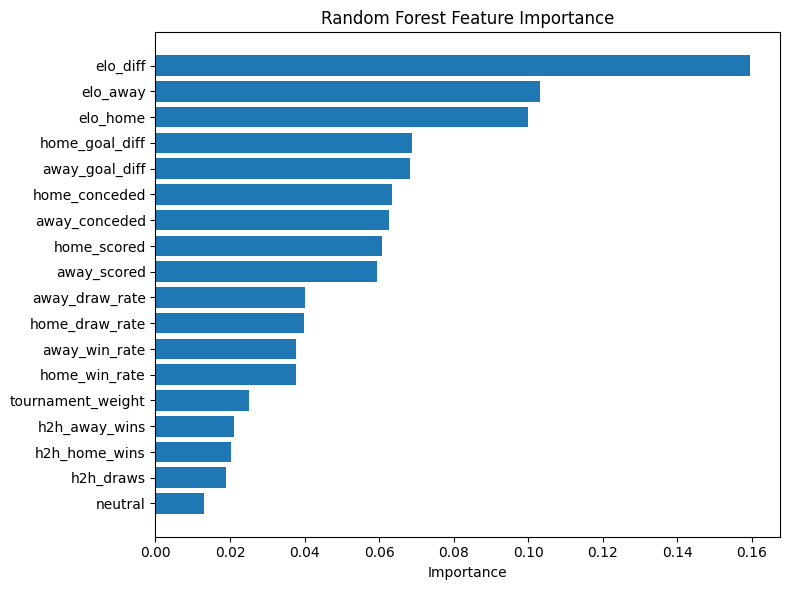

In [1358]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": features,
    "Importance": trained_models["Random Forest"].feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

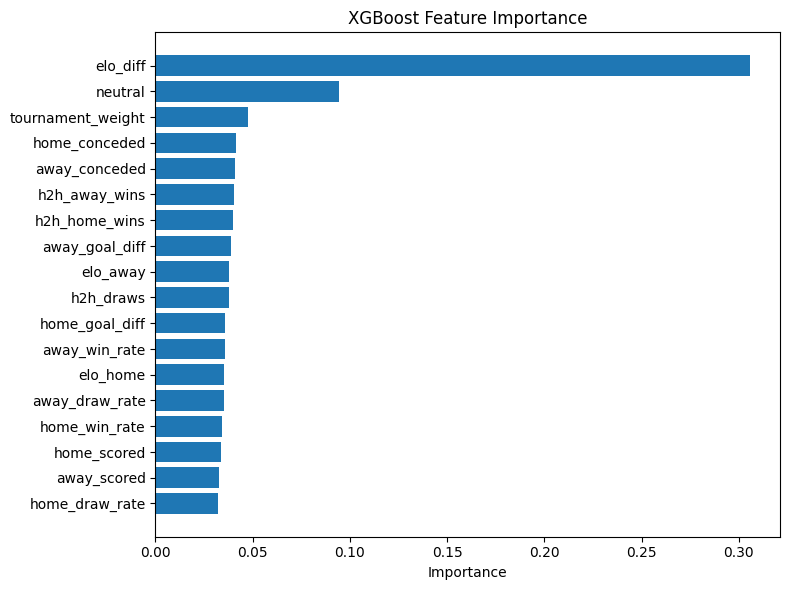

In [1359]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": trained_models["XGBoost"].feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [1360]:
r16_scores = {

    "Canada vs Morocco": ("2026-07-04", "A", 0, 3, 1),
    "Paraguay vs France": ("2026-07-04", "A", 0, 1, 1),

    "Brazil vs Norway": ("2026-07-05", "A", 1, 2, 1),
    "Mexico vs England": ("2026-07-05", "A", 2, 3, 0),

    # Spain won on penalties
    "Portugal vs Spain": ("2026-07-06", "A", 0, 0, 1),

    "United States vs Belgium": ("2026-07-06", "A", 1, 4, 0),

    "Argentina vs Egypt": ("2026-07-07", "H", 3, 2, 1),

    # Switzerland won on penalties
    "Switzerland vs Colombia": ("2026-07-07", "H", 0, 0, 1)
}

r16_rows = []

for match, values in r16_scores.items():

    date, result, hs, as_, neutral = values

    home, away = match.split(" vs ")

    r16_rows.append({
        "date": pd.to_datetime(date),
        "home_team": home,
        "away_team": away,
        "home_score": hs,
        "away_score": as_,
        "result": result,
        "tournament": "FIFA World Cup",
        "neutral": neutral
    })

wc_r16 = (
    pd.DataFrame(r16_rows)
      .sort_values("date")
      .reset_index(drop=True)
)

wc_r16

,date,home_team,away_team,home_score,away_score,result,tournament,neutral
0,2026-07-04,Canada,Morocco,0,3,A,FIFA World Cup,1
1,2026-07-04,Paraguay,France,0,1,A,FIFA World Cup,1
2,2026-07-05,Brazil,Norway,1,2,A,FIFA World Cup,1
3,2026-07-05,Mexico,England,2,3,A,FIFA World Cup,0
4,2026-07-06,Portugal,Spain,0,0,A,FIFA World Cup,1
5,2026-07-06,United States,Belgium,1,4,A,FIFA World Cup,0
6,2026-07-07,Argentina,Egypt,3,2,H,FIFA World Cup,1
7,2026-07-07,Switzerland,Colombia,0,0,H,FIFA World Cup,1


In [1361]:
elo_data = pd.concat(
    [elo_data, wc_r16],
    ignore_index=True
)

elo_data = (
    elo_data
    .sort_values("date")
    .reset_index(drop=True)
)

print(elo_data.shape)
elo_data.tail(10)


(25439, 27)


,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,...,away_goal_diff,away_win_rate,away_draw_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
25429,NaN,2026-07-03,Portugal,Croatia,2.0,1.0,FIFA World Cup,1,H,NaN,...,0.4,0.7,0.0,5.0,1.0,1.0,1.0,1449.371202,1367.016253,82.354948
25430,NaN,2026-07-03,Colombia,Ghana,1.0,0.0,FIFA World Cup,1,H,NaN,...,-0.9,0.2,0.2,5.0,0.0,0.0,0.0,1460.224716,1107.927890,352.296826
25431,NaN,2026-07-04,Canada,Morocco,0.0,3.0,FIFA World Cup,1,A,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25432,NaN,2026-07-04,Paraguay,France,0.0,1.0,FIFA World Cup,1,A,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25433,NaN,2026-07-05,Brazil,Norway,1.0,2.0,FIFA World Cup,1,A,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25434,NaN,2026-07-05,Mexico,England,2.0,3.0,FIFA World Cup,0,A,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25435,NaN,2026-07-06,Portugal,Spain,0.0,0.0,FIFA World Cup,1,A,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25436,NaN,2026-07-06,United States,Belgium,1.0,4.0,FIFA World Cup,0,A,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25437,NaN,2026-07-07,Argentina,Egypt,3.0,2.0,FIFA World Cup,1,H,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25438,NaN,2026-07-07,Switzerland,Colombia,0.0,0.0,FIFA World Cup,1,H,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1362]:
elo_data.drop_duplicates(inplace=True)
elo_data.tail(20)

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,...,away_goal_diff,away_win_rate,away_draw_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
25419,NaN,2026-06-30,France,Sweden,3.0,0.0,FIFA World Cup,1,H,NaN,...,-0.5,0.3,0.2,5.0,0.0,0.0,0.0,1511.184022,1225.593374,285.590648
25420,NaN,2026-06-30,Ivory Coast,Norway,1.0,2.0,FIFA World Cup,1,A,NaN,...,0.8,0.5,0.3,5.0,0.0,0.0,0.0,1306.917440,1372.816308,-65.898868
25421,NaN,2026-07-01,Mexico,Ecuador,2.0,0.0,FIFA World Cup,0,H,NaN,...,0.4,0.3,0.5,5.0,0.0,1.0,3.0,1424.808005,1349.923753,74.884252
25422,NaN,2026-07-01,England,DR Congo,2.0,1.0,FIFA World Cup,1,H,NaN,...,0.3,0.4,0.3,5.0,0.0,0.0,0.0,1450.877821,1230.600828,220.276993
25423,NaN,2026-07-02,Belgium,Senegal,3.0,2.0,FIFA World Cup,1,H,NaN,...,0.4,0.5,0.1,5.0,0.0,0.0,0.0,1373.423182,1308.587810,64.835373
25424,NaN,2026-07-02,United States,Bosnia and Herzegovina,2.0,0.0,FIFA World Cup,0,H,NaN,...,0.4,0.3,0.6,5.0,1.0,0.0,0.0,1376.123219,1135.005499,241.117720
25425,NaN,2026-07-03,Australia,Egypt,1.0,1.0,FIFA World Cup,1,A,NaN,...,0.7,0.4,0.4,5.0,0.0,0.0,0.0,1333.941771,1284.394216,49.547555
25426,NaN,2026-07-03,Switzerland,Algeria,2.0,1.0,FIFA World Cup,1,H,NaN,...,1.1,0.6,0.2,5.0,0.0,0.0,0.0,1333.758755,1343.709503,-9.950748
25427,NaN,2026-07-03,Argentina,Cape Verde,3.0,2.0,FIFA World Cup,1,H,NaN,...,-0.3,0.2,0.4,5.0,0.0,0.0,0.0,1578.833654,1116.691531,462.142123
25428,NaN,2026-07-03,Spain,Austria,3.0,0.0,FIFA World Cup,1,H,NaN,...,1.7,0.6,0.2,5.0,0.0,0.0,0.0,1529.083384,1339.133574,189.949810


In [1363]:
elo_data, final_elo = calculate_elo(elo_data)
elo_data["elo_diff"] = (
    elo_data["elo_home"] -
    elo_data["elo_away"]
)

In [1364]:
mask = elo_data["home_scored"].isna()

for idx in elo_data[mask].index:

    row = elo_data.loc[idx]

    (
        hs,
        hc,
        hgd,
        hwr,
        hdr
    ) = get_team_form(
        row["home_team"],
        row["date"],
        elo_data.iloc[:idx]
    )

    (
        aws,
        awc,
        awgd,
        awwr,
        awdr
    ) = get_team_form(
        row["away_team"],
        row["date"],
        elo_data.iloc[:idx]
    )

    elo_data.loc[idx, [
        "home_scored",
        "home_conceded",
        "home_goal_diff",
        "home_win_rate",
        "home_draw_rate"
    ]] = [hs, hc, hgd, hwr, hdr]

    elo_data.loc[idx, [
        "away_scored",
        "away_conceded",
        "away_goal_diff",
        "away_win_rate",
        "away_draw_rate"
    ]] = [aws, awc, awgd, awwr, awdr]

In [1365]:
mask = elo_data["h2h_home_wins"].isna()

for idx in elo_data[mask].index:

    row = elo_data.loc[idx]

    h2hw, h2haw, h2hd = get_h2h(
        row["home_team"],
        row["away_team"],
        row["date"],
        elo_data.iloc[:idx]
    )

    elo_data.loc[idx, "h2h_home_wins"] = h2hw
    elo_data.loc[idx, "h2h_away_wins"] = h2haw
    elo_data.loc[idx, "h2h_draws"] = h2hd

In [1366]:
elo_data.tail(20)

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,...,away_goal_diff,away_win_rate,away_draw_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
25419,NaN,2026-06-30,France,Sweden,3.0,0.0,FIFA World Cup,1,H,NaN,...,-0.5,0.3,0.2,5.0,0.0,0.0,0.0,1511.182976,1225.591787,285.591188
25420,NaN,2026-06-30,Ivory Coast,Norway,1.0,2.0,FIFA World Cup,1,A,NaN,...,0.8,0.5,0.3,5.0,0.0,0.0,0.0,1306.912992,1372.814250,-65.901258
25421,NaN,2026-07-01,Mexico,Ecuador,2.0,0.0,FIFA World Cup,0,H,NaN,...,0.4,0.3,0.5,5.0,0.0,1.0,3.0,1424.808387,1349.922840,74.885548
25422,NaN,2026-07-01,England,DR Congo,2.0,1.0,FIFA World Cup,1,H,NaN,...,0.3,0.4,0.3,5.0,0.0,0.0,0.0,1450.876102,1230.595981,220.280121
25423,NaN,2026-07-02,Belgium,Senegal,3.0,2.0,FIFA World Cup,1,H,NaN,...,0.4,0.5,0.1,5.0,0.0,0.0,0.0,1373.421468,1308.585099,64.836368
25424,NaN,2026-07-02,United States,Bosnia and Herzegovina,2.0,0.0,FIFA World Cup,0,H,NaN,...,0.4,0.3,0.6,5.0,1.0,0.0,0.0,1376.124603,1135.004347,241.120256
25425,NaN,2026-07-03,Australia,Egypt,1.0,1.0,FIFA World Cup,1,A,NaN,...,0.7,0.4,0.4,5.0,0.0,0.0,0.0,1333.945439,1284.391461,49.553978
25426,NaN,2026-07-03,Switzerland,Algeria,2.0,1.0,FIFA World Cup,1,H,NaN,...,1.1,0.6,0.2,5.0,0.0,0.0,0.0,1333.758174,1343.707794,-9.949619
25427,NaN,2026-07-03,Argentina,Cape Verde,3.0,2.0,FIFA World Cup,1,H,NaN,...,-0.3,0.2,0.4,5.0,0.0,0.0,0.0,1578.833986,1116.689842,462.144144
25428,NaN,2026-07-03,Spain,Austria,3.0,0.0,FIFA World Cup,1,H,NaN,...,1.7,0.6,0.2,5.0,0.0,0.0,0.0,1529.082901,1339.132522,189.950379


In [1367]:
elo_data[features].isna().sum()

home_scored          0
home_conceded        0
home_win_rate        0
away_scored          0
away_conceded        0
away_win_rate        0
neutral              0
tournament_weight    8
h2h_home_wins        0
h2h_away_wins        0
h2h_draws            0
elo_home             0
elo_away             0
elo_diff             0
home_draw_rate       0
away_draw_rate       0
home_goal_diff       0
away_goal_diff       0
dtype: int64

In [1368]:
elo_data["tournament_weight"] = (
    elo_data["tournament"]
    .map(tournament_weight)
    .fillna(2)
)

In [1369]:
qf_fixtures = pd.DataFrame([
    {"home_team":"France",      "away_team":"Morocco",     "date":"2026-07-09", "neutral":1},
    {"home_team":"Spain",       "away_team":"Belgium",     "date":"2026-07-10", "neutral":1},
    {"home_team":"Norway",      "away_team":"England",     "date":"2026-07-10", "neutral":1},
    {"home_team":"Argentina",   "away_team":"Switzerland", "date":"2026-07-11", "neutral":1},
])

qf_fixtures["date"] = pd.to_datetime(qf_fixtures["date"])
qf_fixtures["tournament"] = "FIFA World Cup"
qf_fixtures["tournament_weight"] = 5

qf_fixtures

,home_team,away_team,date,neutral,tournament,tournament_weight
0,France,Morocco,2026-07-09,1,FIFA World Cup,5
1,Spain,Belgium,2026-07-10,1,FIFA World Cup,5
2,Norway,England,2026-07-10,1,FIFA World Cup,5
3,Argentina,Switzerland,2026-07-11,1,FIFA World Cup,5


In [1370]:
mask = elo_data["home_scored"].isna()

for idx in elo_data[mask].index:

    row = elo_data.loc[idx]

    (
        hs,
        hc,
        hgd,
        hwr,
        hdr
    ) = get_team_form(
        row["home_team"],
        row["date"],
        elo_data.iloc[:idx]
    )

    (
        aws,
        awc,
        awgd,
        awwr,
        awdr
    ) = get_team_form(
        row["away_team"],
        row["date"],
        elo_data.iloc[:idx]
    )

    elo_data.loc[idx, [
        "home_scored",
        "home_conceded",
        "home_goal_diff",
        "home_win_rate",
        "home_draw_rate"
    ]] = [hs, hc, hgd, hwr, hdr]

    elo_data.loc[idx, [
        "away_scored",
        "away_conceded",
        "away_goal_diff",
        "away_win_rate",
        "away_draw_rate"
    ]] = [aws, awc, awgd, awwr, awdr]

In [1371]:
mask = elo_data["h2h_home_wins"].isna()

for idx in elo_data[mask].index:

    row = elo_data.loc[idx]

    h2hw, h2haw, h2hd = get_h2h(
        row["home_team"],
        row["away_team"],
        row["date"],
        elo_data.iloc[:idx]
    )

    elo_data.loc[idx, "h2h_home_wins"] = h2hw
    elo_data.loc[idx, "h2h_away_wins"] = h2haw
    elo_data.loc[idx, "h2h_draws"] = h2hd

In [1372]:
def engineer_prediction_features(fixtures, elo_data, final_elo):

    home_scored = []
    home_conceded = []
    home_goal_diff = []
    home_win_rate = []
    home_draw_rate = []

    away_scored = []
    away_conceded = []
    away_goal_diff = []
    away_win_rate = []
    away_draw_rate = []

    h2h_home_wins = []
    h2h_away_wins = []
    h2h_draws = []

    for _, row in fixtures.iterrows():

        hs, hc, hgd, hw, hd = get_team_form(
            row["home_team"],
            row["date"],
            elo_data
        )

        as_, ac, agd, aw, ad = get_team_form(
            row["away_team"],
            row["date"],
            elo_data
        )

        h2hw, h2haw, h2hd = get_h2h(
            row["home_team"],
            row["away_team"],
            row["date"],
            elo_data
        )

        home_scored.append(hs)
        home_conceded.append(hc)
        home_goal_diff.append(hgd)
        home_win_rate.append(hw)
        home_draw_rate.append(hd)

        away_scored.append(as_)
        away_conceded.append(ac)
        away_goal_diff.append(agd)
        away_win_rate.append(aw)
        away_draw_rate.append(ad)

        h2h_home_wins.append(h2hw)
        h2h_away_wins.append(h2haw)
        h2h_draws.append(h2hd)

    fixtures["home_scored"] = home_scored
    fixtures["home_conceded"] = home_conceded
    fixtures["home_goal_diff"] = home_goal_diff
    fixtures["home_win_rate"] = home_win_rate
    fixtures["home_draw_rate"] = home_draw_rate

    fixtures["away_scored"] = away_scored
    fixtures["away_conceded"] = away_conceded
    fixtures["away_goal_diff"] = away_goal_diff
    fixtures["away_win_rate"] = away_win_rate
    fixtures["away_draw_rate"] = away_draw_rate

    fixtures["h2h_home_wins"] = h2h_home_wins
    fixtures["h2h_away_wins"] = h2h_away_wins
    fixtures["h2h_draws"] = h2h_draws

    fixtures["neutral"] = fixtures["neutral"].astype(int)

    fixtures["tournament_weight"] = (
        fixtures["tournament"]
        .map(tournament_weight)
        .fillna(2)
    )

    fixtures["elo_home"] = fixtures["home_team"].map(final_elo).fillna(1000)
    fixtures["elo_away"] = fixtures["away_team"].map(final_elo).fillna(1000)
    fixtures["elo_diff"] = (
        fixtures["elo_home"] -
        fixtures["elo_away"]
    )

    return fixtures

In [1373]:
# elo_data['tournament_weight'].fillna(5)
elo_data['tournament_weight']=elo_data['tournament_weight'].fillna(5)

In [1374]:
elo_data.tail(20)

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,...,away_goal_diff,away_win_rate,away_draw_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
25419,NaN,2026-06-30,France,Sweden,3.0,0.0,FIFA World Cup,1,H,NaN,...,-0.5,0.3,0.2,5.0,0.0,0.0,0.0,1511.182976,1225.591787,285.591188
25420,NaN,2026-06-30,Ivory Coast,Norway,1.0,2.0,FIFA World Cup,1,A,NaN,...,0.8,0.5,0.3,5.0,0.0,0.0,0.0,1306.912992,1372.814250,-65.901258
25421,NaN,2026-07-01,Mexico,Ecuador,2.0,0.0,FIFA World Cup,0,H,NaN,...,0.4,0.3,0.5,5.0,0.0,1.0,3.0,1424.808387,1349.922840,74.885548
25422,NaN,2026-07-01,England,DR Congo,2.0,1.0,FIFA World Cup,1,H,NaN,...,0.3,0.4,0.3,5.0,0.0,0.0,0.0,1450.876102,1230.595981,220.280121
25423,NaN,2026-07-02,Belgium,Senegal,3.0,2.0,FIFA World Cup,1,H,NaN,...,0.4,0.5,0.1,5.0,0.0,0.0,0.0,1373.421468,1308.585099,64.836368
25424,NaN,2026-07-02,United States,Bosnia and Herzegovina,2.0,0.0,FIFA World Cup,0,H,NaN,...,0.4,0.3,0.6,5.0,1.0,0.0,0.0,1376.124603,1135.004347,241.120256
25425,NaN,2026-07-03,Australia,Egypt,1.0,1.0,FIFA World Cup,1,A,NaN,...,0.7,0.4,0.4,5.0,0.0,0.0,0.0,1333.945439,1284.391461,49.553978
25426,NaN,2026-07-03,Switzerland,Algeria,2.0,1.0,FIFA World Cup,1,H,NaN,...,1.1,0.6,0.2,5.0,0.0,0.0,0.0,1333.758174,1343.707794,-9.949619
25427,NaN,2026-07-03,Argentina,Cape Verde,3.0,2.0,FIFA World Cup,1,H,NaN,...,-0.3,0.2,0.4,5.0,0.0,0.0,0.0,1578.833986,1116.689842,462.144144
25428,NaN,2026-07-03,Spain,Austria,3.0,0.0,FIFA World Cup,1,H,NaN,...,1.7,0.6,0.2,5.0,0.0,0.0,0.0,1529.082901,1339.132522,189.950379


In [1375]:
elo_data.tail()

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,...,away_goal_diff,away_win_rate,away_draw_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
25434,NaN,2026-07-05,Mexico,England,2.0,3.0,FIFA World Cup,0,A,NaN,...,1.2,0.7,0.2,5.0,0.0,0.0,0.0,1440.563165,1457.903108,-17.339942
25435,NaN,2026-07-06,Portugal,Spain,0.0,0.0,FIFA World Cup,1,A,NaN,...,1.8,0.6,0.4,5.0,0.0,1.0,2.0,1461.647268,1541.129491,-79.482223
25436,NaN,2026-07-06,United States,Belgium,1.0,4.0,FIFA World Cup,0,A,NaN,...,2.3,0.6,0.4,5.0,0.0,1.0,0.0,1384.113694,1386.469827,-2.356133
25437,NaN,2026-07-07,Argentina,Egypt,3.0,2.0,FIFA World Cup,1,H,NaN,...,0.6,0.4,0.4,5.0,0.0,0.0,0.0,1580.925380,1299.791505,281.133875
25438,NaN,2026-07-07,Switzerland,Colombia,0.0,0.0,FIFA World Cup,1,H,NaN,...,1.0,0.7,0.1,5.0,0.0,0.0,0.0,1350.216246,1463.946373,-113.730127


In [1376]:
qf_fixtures = engineer_prediction_features(
    qf_fixtures,
    elo_data,
    final_elo
)
qf_fixtures


,home_team,away_team,date,neutral,tournament,tournament_weight,home_scored,home_conceded,home_goal_diff,home_win_rate,...,away_conceded,away_goal_diff,away_win_rate,away_draw_rate,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
0,France,Morocco,2026-07-09,1,FIFA World Cup,5,2.6,0.8,1.8,0.9,...,0.5,1.8,0.7,0.3,1,0,0,1526.264440,1473.582622,52.681818
1,Spain,Belgium,2026-07-10,1,FIFA World Cup,5,1.8,0.4,1.4,0.6,...,0.7,2.6,0.7,0.3,0,0,0,1547.732871,1410.307073,137.425798
2,Norway,England,2026-07-10,1,FIFA World Cup,5,2.1,1.4,0.7,0.6,...,0.7,1.1,0.7,0.2,0,0,0,1405.982446,1473.105236,-67.122790
3,Argentina,Switzerland,2026-07-11,1,FIFA World Cup,5,2.8,0.6,2.2,1.0,...,1.2,0.5,0.4,0.4,0,0,0,1586.219281,1369.803368,216.415913


In [1377]:
X_qf = qf_fixtures[features]
X_qf

,home_scored,home_conceded,home_win_rate,away_scored,away_conceded,away_win_rate,neutral,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff,home_draw_rate,away_draw_rate,home_goal_diff,away_goal_diff
0,2.6,0.8,0.9,2.3,0.5,0.7,1,5,1,0,0,1526.264440,1473.582622,52.681818,0.0,0.3,1.8,1.8
1,1.8,0.4,0.6,3.3,0.7,0.7,1,5,0,0,0,1547.732871,1410.307073,137.425798,0.4,0.3,1.4,2.6
2,2.1,1.4,0.6,1.8,0.7,0.7,1,5,0,0,0,1405.982446,1473.105236,-67.122790,0.2,0.2,0.7,1.1
3,2.8,0.6,1.0,1.7,1.2,0.4,1,5,0,0,0,1586.219281,1369.803368,216.415913,0.0,0.4,2.2,0.5


In [1378]:
rf_qf = predict_knockout(
    trained_models["Random Forest"],
    X_qf,
    qf_fixtures["home_team"],
    qf_fixtures["away_team"],
    "Random Forest"
)

rf_qf

,Match,Winner,P(Home),P(Extra time /pen),P(Away)
0,France vs Morocco,Morocco,0.353,0.257,0.390
1,Spain vs Belgium,Belgium,0.307,0.317,0.377
2,Norway vs England,England,0.260,0.330,0.410
3,Argentina vs Switzerland,Argentina,0.643,0.210,0.147


In [1379]:
xgb_qf = predict_knockout(
    trained_models["XGBoost"],
    X_qf,
    qf_fixtures["home_team"],
    qf_fixtures["away_team"],
    "XGBoost"
)

xgb_qf

,Match,Winner,P(Home),P(Extra time /pen),P(Away)
0,France vs Morocco,France,0.483,0.264,0.253
1,Spain vs Belgium,Spain,0.411,0.215,0.374
2,Norway vs England,England,0.325,0.273,0.402
3,Argentina vs Switzerland,Argentina,0.766,0.145,0.089


In [1380]:
comparison_qf = pd.DataFrame({
    "Match": rf_qf["Match"],
    "Random Forest": rf_qf["Winner"],
    "XGBoost": xgb_qf["Winner"]
})

comparison_qf

,Match,Random Forest,XGBoost
0,France vs Morocco,Morocco,France
1,Spain vs Belgium,Belgium,Spain
2,Norway vs England,England,England
3,Argentina vs Switzerland,Argentina,Argentina


In [1381]:
comparison_qf.style.set_properties(**{
    'text-align': 'center',
    'font-size': '12pt'
}).set_table_styles([
    {
        'selector':'th',
        'props':[
            ('background-color','#222'),
            ('color','white'),
            ('font-size','13pt')
        ]
    }
]).hide(axis="index")

Match,Random Forest,XGBoost
France vs Morocco,Morocco,France
Spain vs Belgium,Belgium,Spain
Norway vs England,England,England
Argentina vs Switzerland,Argentina,Argentina


In [1382]:
rf_qf

,Match,Winner,P(Home),P(Extra time /pen),P(Away)
0,France vs Morocco,Morocco,0.353,0.257,0.390
1,Spain vs Belgium,Belgium,0.307,0.317,0.377
2,Norway vs England,England,0.260,0.330,0.410
3,Argentina vs Switzerland,Argentina,0.643,0.210,0.147


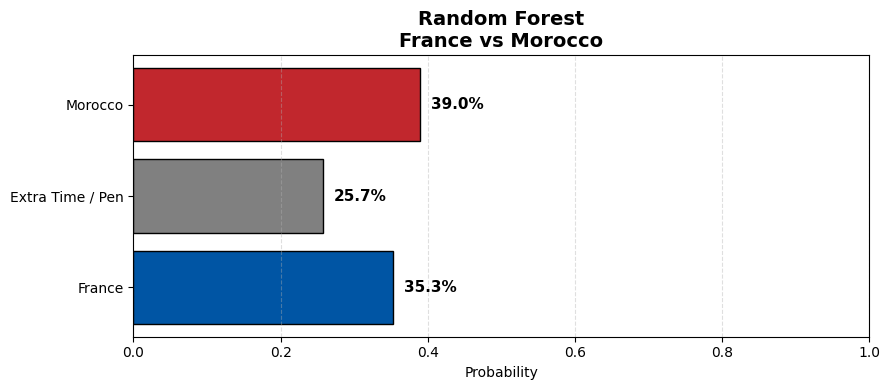

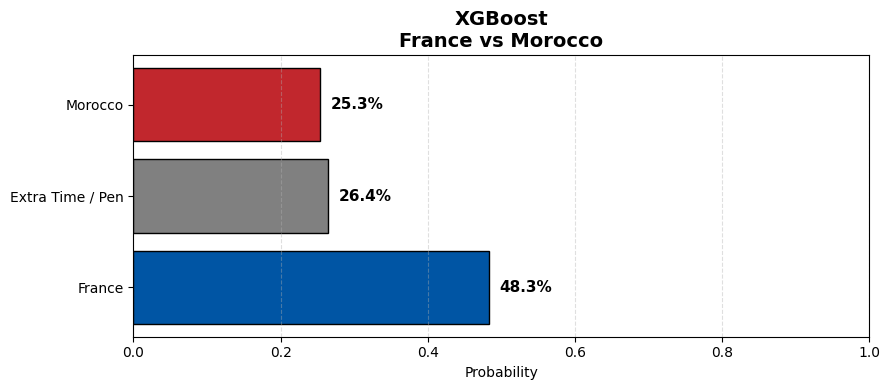

In [1383]:
plot_match_probabilities(
    "France",
    "Morocco",
    rf_qf,
    "Random Forest"
)

plot_match_probabilities(
    "France",
    "Morocco",
    xgb_qf,
    "XGBoost"
)

In [1384]:
comparison_qf["Agreement"] = (
    comparison_qf["Random Forest"] ==
    comparison_qf["XGBoost"]
)

comparison_qf["Agreement"] = comparison_qf["Agreement"].map({
    True:"✅ Agree",
    False:"❌ Different"
})

comparison_qf

,Match,Random Forest,XGBoost,Agreement
0,France vs Morocco,Morocco,France,❌ Different
1,Spain vs Belgium,Belgium,Spain,❌ Different
2,Norway vs England,England,England,✅ Agree
3,Argentina vs Switzerland,Argentina,Argentina,✅ Agree


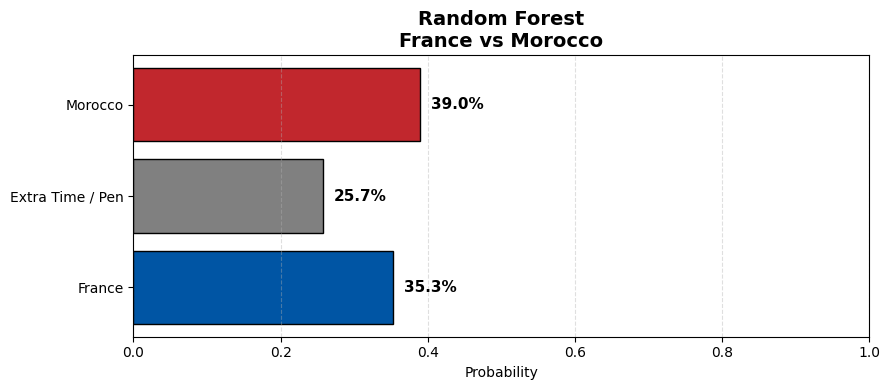

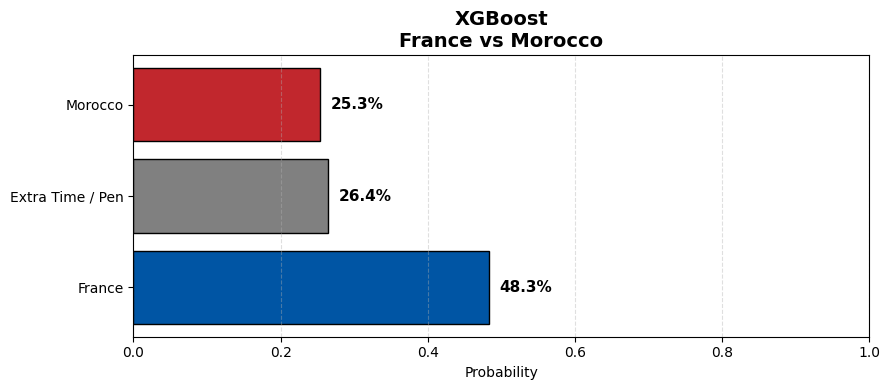

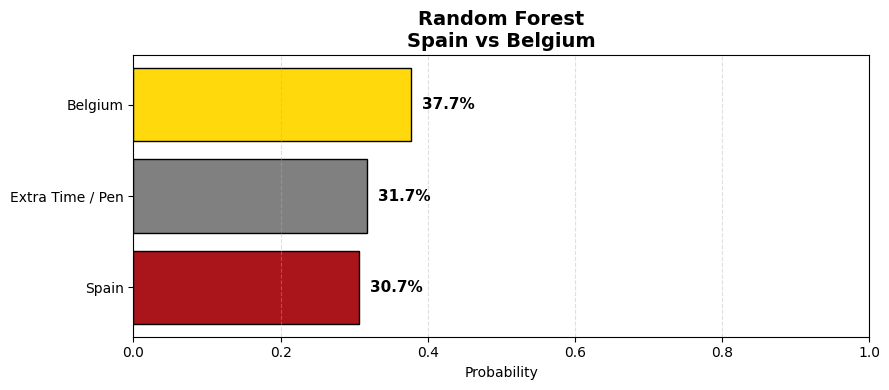

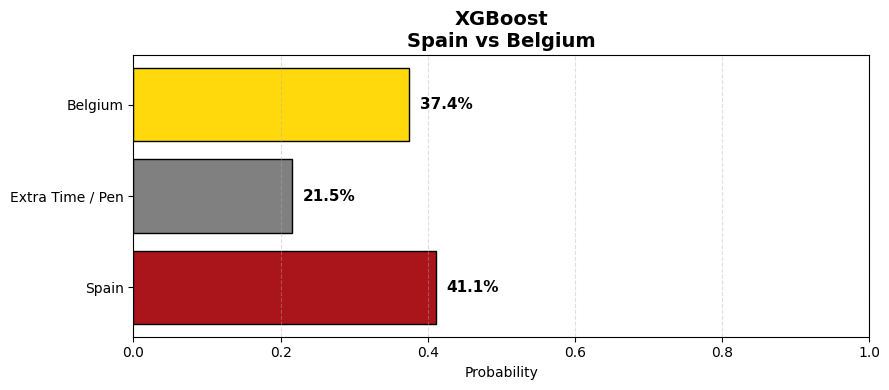

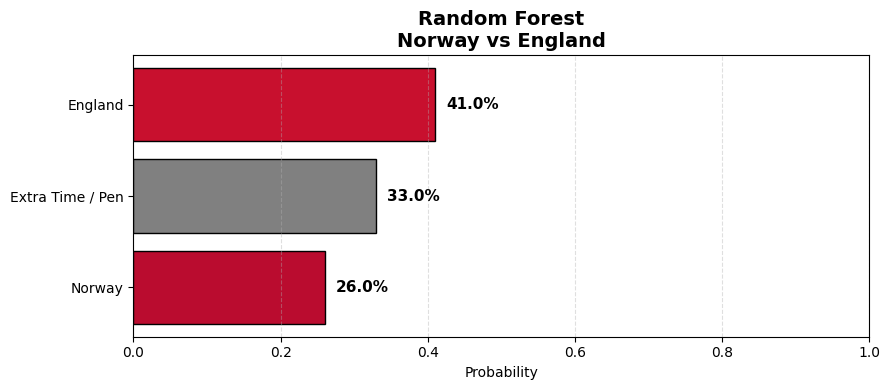

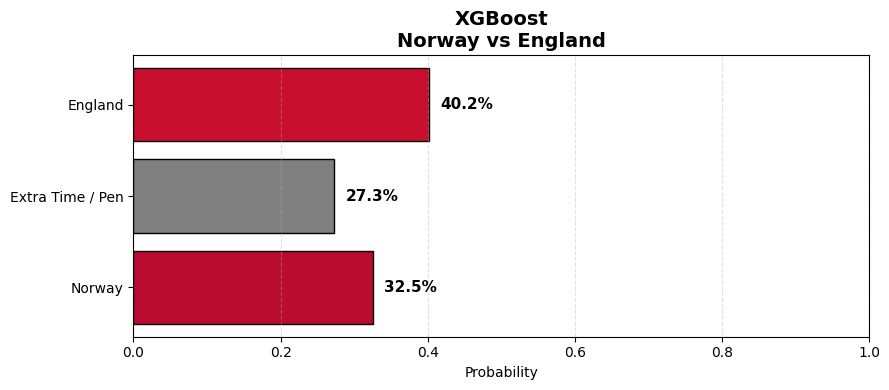

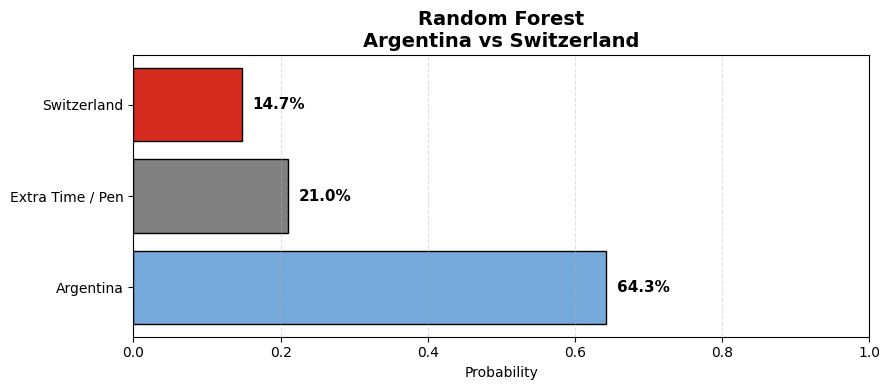

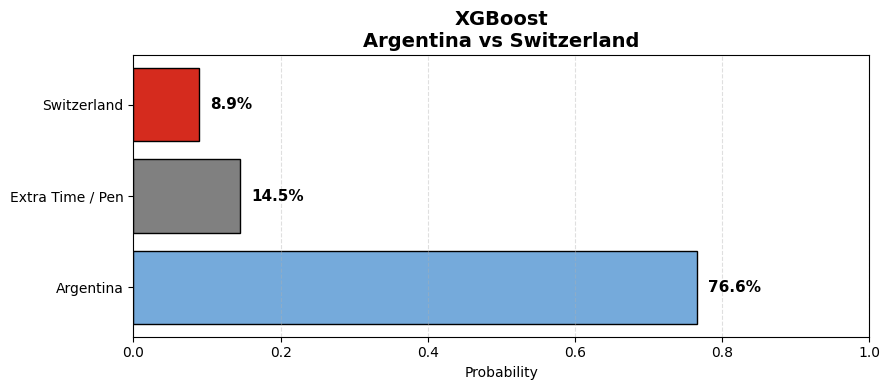

In [1385]:
# France vs Morocco
plot_match_probabilities(
    "France",
    "Morocco",
    rf_qf,
    "Random Forest"
)

plot_match_probabilities(
    "France",
    "Morocco",
    xgb_qf,
    "XGBoost"
)

# Spain vs Belgium
plot_match_probabilities(
    "Spain",
    "Belgium",
    rf_qf,
    "Random Forest"
)

plot_match_probabilities(
    "Spain",
    "Belgium",
    xgb_qf,
    "XGBoost"
)

# Norway vs England
plot_match_probabilities(
    "Norway",
    "England",
    rf_qf,
    "Random Forest"
)

plot_match_probabilities(
    "Norway",
    "England",
    xgb_qf,
    "XGBoost"
)

# Argentina vs Switzerland
plot_match_probabilities(
    "Argentina",
    "Switzerland",
    rf_qf,
    "Random Forest"
)

plot_match_probabilities(
    "Argentina",
    "Switzerland",
    xgb_qf,
    "XGBoost"
)

In [1386]:
wc_qf = pd.DataFrame([
    {
        "date":"2026-07-09",
        "home_team":"France",
        "away_team":"Morocco",
        "home_score":2,
        "away_score":0,
        "tournament":"FIFA World Cup",
        "neutral":1,
        "result":"H"
    },
    {
        "date":"2026-07-10",
        "home_team":"Spain",
        "away_team":"Belgium",
        "home_score":2,
        "away_score":1,
        "tournament":"FIFA World Cup",
        "neutral":1,
        "result":"H"
    },
    {
        "date":"2026-07-11",
        "home_team":"Norway",
        "away_team":"England",
        "home_score":1,
        "away_score":2,
        "tournament":"FIFA World Cup",
        "neutral":1,
        "result":"A"
    },
    {
        "date":"2026-07-11",
        "home_team":"Argentina",
        "away_team":"Switzerland",
        "home_score":3,
        "away_score":1,
        "tournament":"FIFA World Cup",
        "neutral":1,
        "result":"H"
    }
])

wc_qf["date"] = pd.to_datetime(wc_qf["date"])

wc_qf

,date,home_team,away_team,home_score,away_score,tournament,neutral,result
0,2026-07-09,France,Morocco,2,0,FIFA World Cup,1,H
1,2026-07-10,Spain,Belgium,2,1,FIFA World Cup,1,H
2,2026-07-11,Norway,England,1,2,FIFA World Cup,1,A
3,2026-07-11,Argentina,Switzerland,3,1,FIFA World Cup,1,H


In [1387]:
elo_data = pd.concat([elo_data, wc_qf], ignore_index=True)

elo_data = elo_data.sort_values("date").reset_index(drop=True)
elo_data.tail(20)

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,...,away_goal_diff,away_win_rate,away_draw_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
25423,NaN,2026-07-02,Belgium,Senegal,3.0,2.0,FIFA World Cup,1,H,NaN,...,0.4,0.5,0.1,5.0,0.0,0.0,0.0,1373.421468,1308.585099,64.836368
25424,NaN,2026-07-02,United States,Bosnia and Herzegovina,2.0,0.0,FIFA World Cup,0,H,NaN,...,0.4,0.3,0.6,5.0,1.0,0.0,0.0,1376.124603,1135.004347,241.120256
25425,NaN,2026-07-03,Colombia,Ghana,1.0,0.0,FIFA World Cup,1,H,NaN,...,-0.9,0.2,0.2,5.0,0.0,0.0,0.0,1460.224992,1107.923392,352.301599
25426,NaN,2026-07-03,Portugal,Croatia,2.0,1.0,FIFA World Cup,1,H,NaN,...,0.4,0.7,0.0,5.0,1.0,1.0,1.0,1449.370412,1367.014834,82.355577
25427,NaN,2026-07-03,Spain,Austria,3.0,0.0,FIFA World Cup,1,H,NaN,...,1.7,0.6,0.2,5.0,0.0,0.0,0.0,1529.082901,1339.132522,189.950379
25428,NaN,2026-07-03,Switzerland,Algeria,2.0,1.0,FIFA World Cup,1,H,NaN,...,1.1,0.6,0.2,5.0,0.0,0.0,0.0,1333.758174,1343.707794,-9.949619
25429,NaN,2026-07-03,Australia,Egypt,1.0,1.0,FIFA World Cup,1,A,NaN,...,0.7,0.4,0.4,5.0,0.0,0.0,0.0,1333.945439,1284.391461,49.553978
25430,NaN,2026-07-03,Argentina,Cape Verde,3.0,2.0,FIFA World Cup,1,H,NaN,...,-0.3,0.2,0.4,5.0,0.0,0.0,0.0,1578.833986,1116.689842,462.144144
25431,NaN,2026-07-04,Canada,Morocco,0.0,3.0,FIFA World Cup,1,A,NaN,...,1.8,0.7,0.3,5.0,0.0,1.0,0.0,1348.857964,1456.808539,-107.950575
25432,NaN,2026-07-04,Paraguay,France,0.0,1.0,FIFA World Cup,1,A,NaN,...,2.1,0.9,0.0,5.0,0.0,0.0,0.0,1307.489082,1518.955241,-211.466159


In [1388]:
elo_data, final_elo = calculate_elo(elo_data)

elo_data["elo_diff"] = elo_data["elo_home"] - elo_data["elo_away"]

In [1389]:
elo_data.tail(10)

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,...,away_goal_diff,away_win_rate,away_draw_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
25433,NaN,2026-07-05,Brazil,Norway,1.0,2.0,FIFA World Cup,1,A,NaN,...,0.9,0.6,0.2,5.0,0.0,0.0,0.0,1478.437790,1385.817429,92.620361
25434,NaN,2026-07-05,Mexico,England,2.0,3.0,FIFA World Cup,0,A,NaN,...,1.2,0.7,0.2,5.0,0.0,0.0,0.0,1440.562854,1457.904925,-17.342071
25435,NaN,2026-07-06,Portugal,Spain,0.0,0.0,FIFA World Cup,1,A,NaN,...,1.8,0.6,0.4,5.0,0.0,1.0,2.0,1461.648086,1541.130003,-79.481918
25436,NaN,2026-07-06,United States,Belgium,1.0,4.0,FIFA World Cup,0,A,NaN,...,2.3,0.6,0.4,5.0,0.0,1.0,0.0,1384.112403,1386.471586,-2.359183
25437,NaN,2026-07-07,Argentina,Egypt,3.0,2.0,FIFA World Cup,1,H,NaN,...,0.6,0.4,0.4,5.0,0.0,0.0,0.0,1580.925071,1299.793824,281.131246
25438,NaN,2026-07-07,Switzerland,Colombia,0.0,0.0,FIFA World Cup,1,H,NaN,...,1.0,0.7,0.1,5.0,0.0,0.0,0.0,1350.216878,1463.946188,-113.729310
25439,NaN,2026-07-09,France,Morocco,2.0,0.0,FIFA World Cup,1,H,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1526.265436,1473.585024,52.680412
25440,NaN,2026-07-10,Spain,Belgium,2.0,1.0,FIFA World Cup,1,H,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1547.733403,1410.308622,137.424781
25441,NaN,2026-07-11,Norway,England,1.0,2.0,FIFA World Cup,1,A,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1405.984506,1473.106956,-67.122450
25442,NaN,2026-07-11,Argentina,Switzerland,3.0,1.0,FIFA World Cup,1,H,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1586.219038,1369.803950,216.415088


In [1390]:
sf_fixtures = pd.DataFrame([
    {
        "home_team":"France",
        "away_team":"Spain",
        "date":"2026-07-14",
        "neutral":1
    },
    {
        "home_team":"England",
        "away_team":"Argentina",
        "date":"2026-07-15",
        "neutral":1
    }
])

sf_fixtures["date"] = pd.to_datetime(sf_fixtures["date"])
sf_fixtures["tournament"] = "FIFA World Cup"

In [1391]:
mask = elo_data["home_scored"].isna()

for idx in elo_data[mask].index:

    row = elo_data.loc[idx]

    (
        hs,
        hc,
        hgd,
        hwr,
        hdr
    ) = get_team_form(
        row["home_team"],
        row["date"],
        elo_data.iloc[:idx]
    )

    (
        aws,
        awc,
        awgd,
        awwr,
        awdr
    ) = get_team_form(
        row["away_team"],
        row["date"],
        elo_data.iloc[:idx]
    )

    elo_data.loc[idx, [
        "home_scored",
        "home_conceded",
        "home_goal_diff",
        "home_win_rate",
        "home_draw_rate"
    ]] = [hs, hc, hgd, hwr, hdr]

    elo_data.loc[idx, [
        "away_scored",
        "away_conceded",
        "away_goal_diff",
        "away_win_rate",
        "away_draw_rate"
    ]] = [aws, awc, awgd, awwr, awdr]
    mask = elo_data["h2h_home_wins"].isna()

for idx in elo_data[mask].index:

    row = elo_data.loc[idx]

    h2hw, h2haw, h2hd = get_h2h(
        row["home_team"],
        row["away_team"],
        row["date"],
        elo_data.iloc[:idx]
    )

    elo_data.loc[idx, "h2h_home_wins"] = h2hw
    elo_data.loc[idx, "h2h_away_wins"] = h2haw
    elo_data.loc[idx, "h2h_draws"] = h2hd

In [1392]:
sf_fixtures = engineer_prediction_features(
    sf_fixtures,
    elo_data,
    final_elo
)

sf_fixtures

,home_team,away_team,date,neutral,tournament,home_scored,home_conceded,home_goal_diff,home_win_rate,home_draw_rate,...,away_goal_diff,away_win_rate,away_draw_rate,h2h_home_wins,h2h_away_wins,h2h_draws,tournament_weight,elo_home,elo_away,elo_diff
0,France,Spain,2026-07-14,1,FIFA World Cup,2.5,0.7,1.8,0.9,0.0,...,1.5,0.7,0.3,1,2,0,5,1543.255936,1557.715377,-14.459441
1,England,Argentina,2026-07-15,1,FIFA World Cup,1.8,0.8,1.0,0.7,0.2,...,2.2,1.0,0.0,0,0,0,5,1486.053745,1595.156260,-109.102516


In [1393]:
sf_fixtures[features].isna().sum()

home_scored          0
home_conceded        0
home_win_rate        0
away_scored          0
away_conceded        0
away_win_rate        0
neutral              0
tournament_weight    0
h2h_home_wins        0
h2h_away_wins        0
h2h_draws            0
elo_home             0
elo_away             0
elo_diff             0
home_draw_rate       0
away_draw_rate       0
home_goal_diff       0
away_goal_diff       0
dtype: int64

In [1394]:
X_sf = sf_fixtures[features]

In [1395]:
rf_sf = predict_knockout(
    trained_models["Random Forest"],
    X_sf,
    sf_fixtures["home_team"],
    sf_fixtures["away_team"],
    "Random Forest"
)

rf_sf

,Match,Winner,P(Home),P(Extra time /pen),P(Away)
0,France vs Spain,Spain,0.323,0.330,0.347
1,England vs Argentina,Argentina,0.260,0.337,0.403


In [1396]:
xgb_sf = predict_knockout(
    trained_models["XGBoost"],
    X_sf,
    sf_fixtures["home_team"],
    sf_fixtures["away_team"],
    "XGBoost"
)

xgb_sf

,Match,Winner,P(Home),P(Extra time /pen),P(Away)
0,France vs Spain,Spain,0.350,0.257,0.393
1,England vs Argentina,Argentina,0.175,0.379,0.446


In [1397]:
comparison_sf = pd.DataFrame({
    "Match": rf_sf["Match"],
    "Random Forest": rf_sf["Winner"],
    "XGBoost": xgb_sf["Winner"]
})

comparison_sf

,Match,Random Forest,XGBoost
0,France vs Spain,Spain,Spain
1,England vs Argentina,Argentina,Argentina


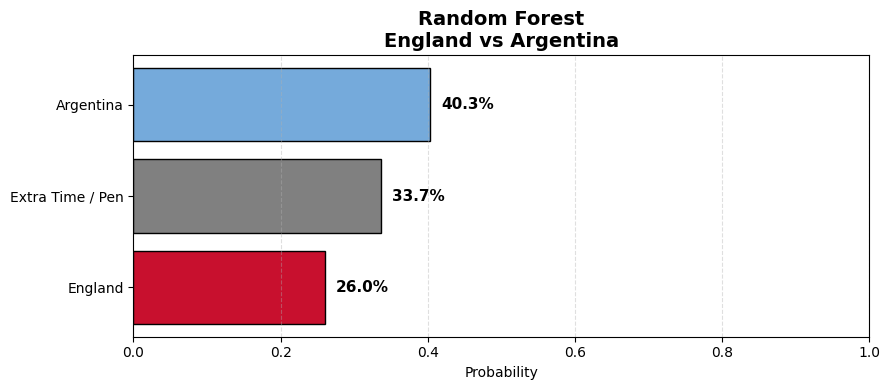

In [1398]:
plot_match_probabilities(
    "England",
    "Argentina",
    rf_sf,
    "Random Forest"
)

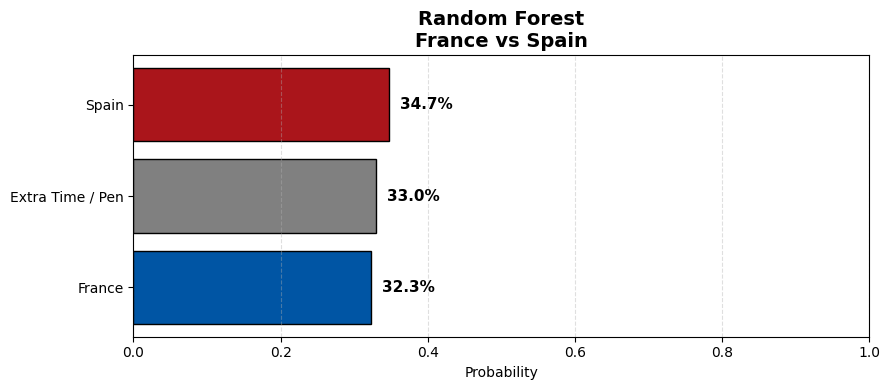

In [1399]:
plot_match_probabilities(
    "France",
    "Spain",
    rf_sf,
    "Random Forest"
)

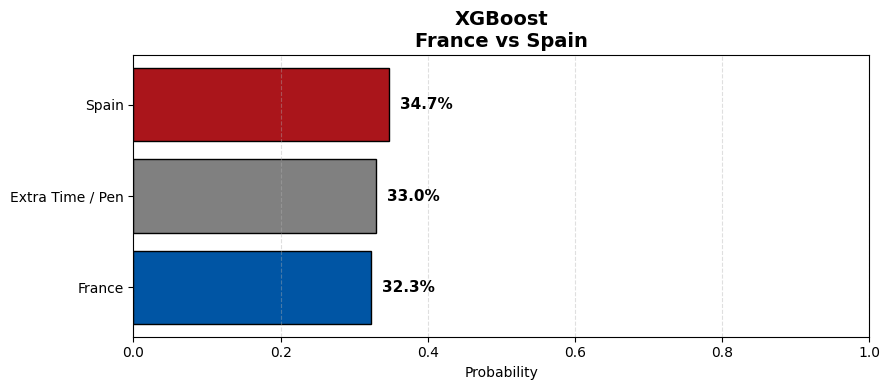

In [1400]:
plot_match_probabilities(
    "France",
    "Spain",
    rf_sf,
    "XGBoost"
)

In [1401]:
wc_sf = pd.DataFrame([
    {
        "date":"2026-07-14",
        "home_team":"France",
        "away_team":"Spain",
        "home_score":0,
        "away_score":2,
        "tournament":"FIFA World Cup",
        "neutral":1,
        "result":"A"
    },
    {
        "date":"2026-07-15",
        "home_team":"England",
        "away_team":"Argentina",
        "home_score":1,
        "away_score":2,
        "tournament":"FIFA World Cup",
        "neutral":1,
        "result":"A"
    }
])

wc_sf["date"] = pd.to_datetime(wc_sf["date"])

In [1402]:
elo_data = pd.concat([elo_data, wc_sf], ignore_index=True)

elo_data = (
    elo_data
    .sort_values("date")
    .reset_index(drop=True)
)

In [1403]:
elo_data, final_elo = calculate_elo(elo_data)

elo_data["elo_diff"] = (
    elo_data["elo_home"] -
    elo_data["elo_away"]
)

In [1404]:
bronze_fixtures = pd.DataFrame([
    {
        "home_team":"France",
        "away_team":"England",
        "date":"2026-07-18",
        "neutral":1
    }
])

bronze_fixtures["date"] = pd.to_datetime(bronze_fixtures["date"])
bronze_fixtures["tournament"] = "FIFA World Cup"

In [1405]:
mask = elo_data["home_scored"].isna()

for idx in elo_data[mask].index:

    row = elo_data.loc[idx]

    (
        hs,
        hc,
        hgd,
        hwr,
        hdr
    ) = get_team_form(
        row["home_team"],
        row["date"],
        elo_data.iloc[:idx]
    )

    (
        aws,
        awc,
        awgd,
        awwr,
        awdr
    ) = get_team_form(
        row["away_team"],
        row["date"],
        elo_data.iloc[:idx]
    )

    elo_data.loc[idx, [
        "home_scored",
        "home_conceded",
        "home_goal_diff",
        "home_win_rate",
        "home_draw_rate"
    ]] = [hs, hc, hgd, hwr, hdr]

    elo_data.loc[idx, [
        "away_scored",
        "away_conceded",
        "away_goal_diff",
        "away_win_rate",
        "away_draw_rate"
    ]] = [aws, awc, awgd, awwr, awdr]
    mask = elo_data["h2h_home_wins"].isna()

for idx in elo_data[mask].index:

    row = elo_data.loc[idx]

    h2hw, h2haw, h2hd = get_h2h(
        row["home_team"],
        row["away_team"],
        row["date"],
        elo_data.iloc[:idx]
    )

    elo_data.loc[idx, "h2h_home_wins"] = h2hw
    elo_data.loc[idx, "h2h_away_wins"] = h2haw
    elo_data.loc[idx, "h2h_draws"] = h2hd

In [1406]:
final_fixtures = pd.DataFrame([
    {
        "home_team":"Argentina",
        "away_team":"Spain",
        "date":"2026-07-19",
        "neutral":1
    }
])

final_fixtures["date"] = pd.to_datetime(final_fixtures["date"])
final_fixtures["tournament"] = "FIFA World Cup"

In [1407]:
bronze_fixtures = engineer_prediction_features(
    bronze_fixtures,
    elo_data,
    final_elo
)

final_fixtures = engineer_prediction_features(
    final_fixtures,
    elo_data,
    final_elo
)

In [1408]:
X_bronze = bronze_fixtures[features]
X_final = final_fixtures[features]

In [1409]:
rf_bronze = predict_knockout(
    trained_models["Random Forest"],
    X_bronze,
    bronze_fixtures["home_team"],
    bronze_fixtures["away_team"],
    "Random Forest"
)

xgb_bronze = predict_knockout(
    trained_models["XGBoost"],
    X_bronze,
    bronze_fixtures["home_team"],
    bronze_fixtures["away_team"],
    "XGBoost"
)


In [1410]:
rf_final = predict_knockout(
    trained_models["Random Forest"],
    X_final,
    final_fixtures["home_team"],
    final_fixtures["away_team"],
    "Random Forest"
)

xgb_final = predict_knockout(
    trained_models["XGBoost"],
    X_final,
    final_fixtures["home_team"],
    final_fixtures["away_team"],
    "XGBoost"
)

In [1411]:
print("=" * 60)
print("Third Place Prediction")
display(rf_bronze)
display(xgb_bronze)

print("=" * 60)
print("World Cup Final Prediction")
display(rf_final)
display(xgb_final)

Third Place Prediction


,Match,Winner,P(Home),P(Extra time /pen),P(Away)
0,France vs England,France,0.387,0.28,0.333


,Match,Winner,P(Home),P(Extra time /pen),P(Away)
0,France vs England,France,0.356,0.326,0.318


World Cup Final Prediction


,Match,Winner,P(Home),P(Extra time /pen),P(Away)
0,Argentina vs Spain,Spain,0.333,0.287,0.38


,Match,Winner,P(Home),P(Extra time /pen),P(Away)
0,Argentina vs Spain,Spain,0.369,0.251,0.38


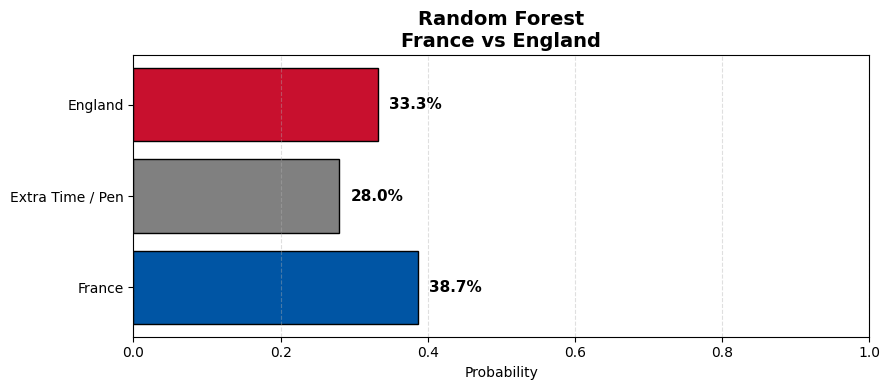

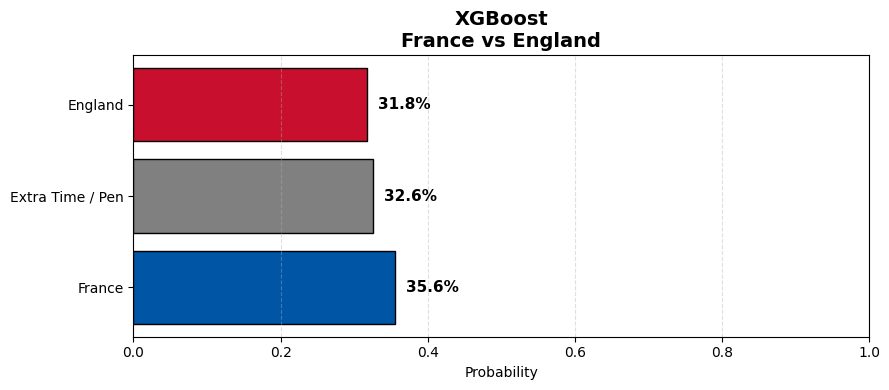

In [1412]:
plot_match_probabilities(
    "France",
    "England",
    rf_bronze,
    "Random Forest"
)
plot_match_probabilities(
    "France",
    "England",
    xgb_bronze,
    "XGBoost"
)

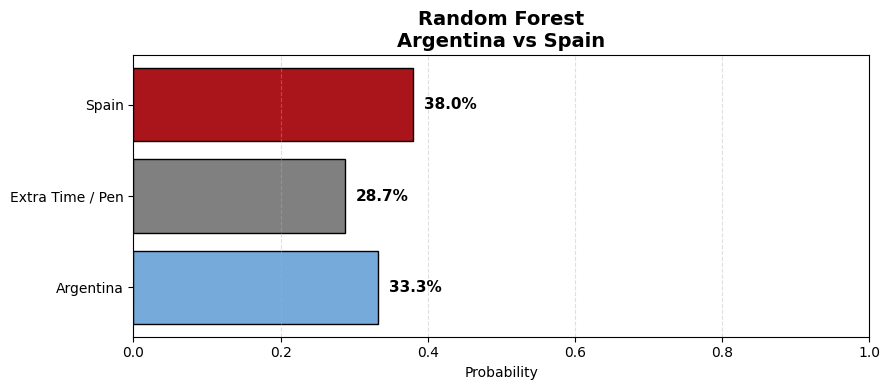

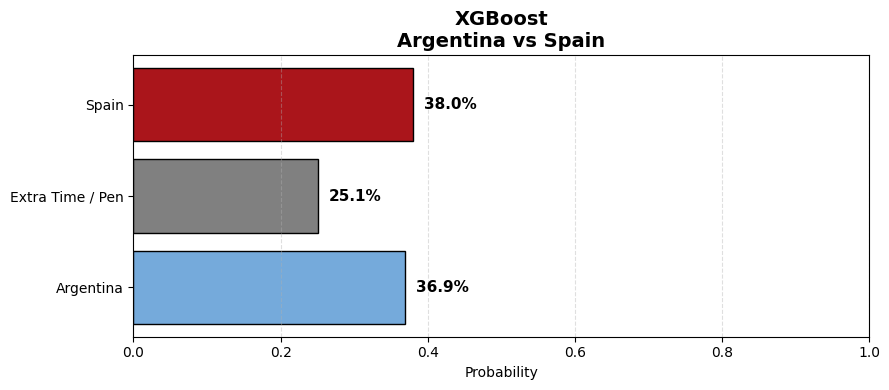

In [1413]:
plot_match_probabilities(
    "Argentina",
    "Spain",
    rf_final,
    "Random Forest"
)
plot_match_probabilities(
    "Argentina",
    "Spain",
    xgb_final,
    "XGBoost"
)

In [1414]:
def ensemble_predict_knockout(models, X, home_teams, away_teams):

    # Get probabilities from each model
    probs = [model.predict_proba(X) for model in models]

    # Average probabilities
    avg_probs = sum(probs) / len(probs)

    class_labels = models[0].classes_

    predictions = []

    for i in range(len(X)):

        prob_dict = dict(zip(class_labels, avg_probs[i]))

        home_prob = prob_dict.get("H", 0)
        draw_prob = prob_dict.get("D", 0)
        away_prob = prob_dict.get("A", 0)

        # Knockout logic
        if max(prob_dict, key=prob_dict.get) == "D":
            winner = home_teams.iloc[i] if home_prob >= away_prob else away_teams.iloc[i]
        else:
            winner = home_teams.iloc[i] if home_prob >= away_prob else away_teams.iloc[i]

        predictions.append({
            "Match": f"{home_teams.iloc[i]} vs {away_teams.iloc[i]}",
            "Winner": winner,
            "P(Home)": round(home_prob * 100, 2),
            "P(Extra time /pen)": round(draw_prob * 100, 2),
            "P(Away)": round(away_prob * 100, 2)
        })

    return pd.DataFrame(predictions)

In [1415]:
ensemble_bronze = ensemble_predict_knockout(
    [
        trained_models["Random Forest"],
        trained_models["XGBoost"]
    ],
    X_bronze,
    bronze_fixtures["home_team"],
    bronze_fixtures["away_team"]
)

ensemble_bronze

,Match,Winner,P(Home),P(Extra time /pen),P(Away)
0,France vs England,France,37.13,30.3,32.56


In [1416]:
ensemble_final = ensemble_predict_knockout(
    [
        trained_models["Random Forest"],
        trained_models["XGBoost"]
    ],
    X_final,
    final_fixtures["home_team"],
    final_fixtures["away_team"]
)

ensemble_final

,Match,Winner,P(Home),P(Extra time /pen),P(Away)
0,Argentina vs Spain,Spain,35.12,26.88,38.0


In [1417]:
elo_data.tail(10)
# elo_data['tournament_weight'].fillna(5)
elo_data['tournament_weight']=elo_data['tournament_weight'].fillna(5)

In [1418]:
elo_data.tail(5)

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,...,away_goal_diff,away_win_rate,away_draw_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
25440,NaN,2026-07-10,Spain,Belgium,2.0,1.0,FIFA World Cup,1,H,NaN,...,2.6,0.7,0.3,5.0,0.0,0.0,0.0,1547.732871,1410.307073,137.425798
25441,NaN,2026-07-11,Norway,England,1.0,2.0,FIFA World Cup,1,A,NaN,...,1.1,0.7,0.2,5.0,0.0,0.0,0.0,1405.982446,1473.105236,-67.122790
25442,NaN,2026-07-11,Argentina,Switzerland,3.0,1.0,FIFA World Cup,1,H,NaN,...,0.5,0.4,0.4,5.0,0.0,0.0,0.0,1586.219281,1369.803368,216.415913
25443,NaN,2026-07-14,France,Spain,0.0,2.0,FIFA World Cup,1,A,NaN,...,1.5,0.7,0.3,5.0,1.0,2.0,0.0,1543.254860,1557.714805,-14.459944
25444,NaN,2026-07-15,England,Argentina,1.0,2.0,FIFA World Cup,1,A,NaN,...,2.2,1.0,0.0,5.0,0.0,0.0,0.0,1486.052010,1595.156470,-109.104460


In [1419]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error
import numpy as np

In [1420]:
X = elo_data[features]

y_home = elo_data["home_score"]
y_away = elo_data["away_score"]

In [1421]:
print(X.shape)

print(y_home.shape)
print(y_away.shape)

print(X.isnull().sum())

print(y_home.isnull().sum())
print(y_away.isnull().sum())

(25445, 18)
(25445,)
(25445,)
home_scored          0
home_conceded        0
home_win_rate        0
away_scored          0
away_conceded        0
away_win_rate        0
neutral              0
tournament_weight    0
h2h_home_wins        0
h2h_away_wins        0
h2h_draws            0
elo_home             0
elo_away             0
elo_diff             0
home_draw_rate       0
away_draw_rate       0
home_goal_diff       0
away_goal_diff       0
dtype: int64
0
0


In [1422]:
elo_data.tail(20)

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,...,away_goal_diff,away_win_rate,away_draw_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
25425,NaN,2026-07-03,Argentina,Cape Verde,3.0,2.0,FIFA World Cup,1,H,NaN,...,-0.3,0.2,0.4,5.0,0.0,0.0,0.0,1578.833986,1116.689842,462.144144
25426,NaN,2026-07-03,Switzerland,Algeria,2.0,1.0,FIFA World Cup,1,H,NaN,...,1.1,0.6,0.2,5.0,0.0,0.0,0.0,1333.758174,1343.707794,-9.949619
25427,NaN,2026-07-03,Australia,Egypt,1.0,1.0,FIFA World Cup,1,A,NaN,...,0.7,0.4,0.4,5.0,0.0,0.0,0.0,1333.945439,1284.391461,49.553978
25428,NaN,2026-07-03,Portugal,Croatia,2.0,1.0,FIFA World Cup,1,H,NaN,...,0.4,0.7,0.0,5.0,1.0,1.0,1.0,1449.370412,1367.014834,82.355577
25429,NaN,2026-07-03,Colombia,Ghana,1.0,0.0,FIFA World Cup,1,H,NaN,...,-0.9,0.2,0.2,5.0,0.0,0.0,0.0,1460.224992,1107.923392,352.301599
25430,NaN,2026-07-03,Spain,Austria,3.0,0.0,FIFA World Cup,1,H,NaN,...,1.7,0.6,0.2,5.0,0.0,0.0,0.0,1529.082901,1339.132522,189.950379
25431,NaN,2026-07-04,Canada,Morocco,0.0,3.0,FIFA World Cup,1,A,NaN,...,1.8,0.7,0.3,5.0,0.0,1.0,0.0,1348.857964,1456.808539,-107.950575
25432,NaN,2026-07-04,Paraguay,France,0.0,1.0,FIFA World Cup,1,A,NaN,...,2.1,0.9,0.0,5.0,0.0,0.0,0.0,1307.489082,1518.955241,-211.466159
25433,NaN,2026-07-05,Brazil,Norway,1.0,2.0,FIFA World Cup,1,A,NaN,...,0.9,0.6,0.2,5.0,0.0,0.0,0.0,1478.438070,1385.815265,92.622805
25434,NaN,2026-07-05,Mexico,England,2.0,3.0,FIFA World Cup,0,A,NaN,...,1.2,0.7,0.2,5.0,0.0,0.0,0.0,1440.563165,1457.903108,-17.339942


In [1423]:
elo_data[elo_data[features].isnull().any(axis=1)]

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,...,away_goal_diff,away_win_rate,away_draw_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff


In [1424]:
elo_data[elo_data[features].isna().any(axis=1)][
    ["date","home_team","away_team"] + features
]

,date,home_team,away_team,home_scored,home_conceded,home_win_rate,away_scored,away_conceded,away_win_rate,neutral,...,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff,home_draw_rate,away_draw_rate,home_goal_diff,away_goal_diff


In [1425]:
elo_data.tail(20)

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,...,away_goal_diff,away_win_rate,away_draw_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
25425,NaN,2026-07-03,Argentina,Cape Verde,3.0,2.0,FIFA World Cup,1,H,NaN,...,-0.3,0.2,0.4,5.0,0.0,0.0,0.0,1578.833986,1116.689842,462.144144
25426,NaN,2026-07-03,Switzerland,Algeria,2.0,1.0,FIFA World Cup,1,H,NaN,...,1.1,0.6,0.2,5.0,0.0,0.0,0.0,1333.758174,1343.707794,-9.949619
25427,NaN,2026-07-03,Australia,Egypt,1.0,1.0,FIFA World Cup,1,A,NaN,...,0.7,0.4,0.4,5.0,0.0,0.0,0.0,1333.945439,1284.391461,49.553978
25428,NaN,2026-07-03,Portugal,Croatia,2.0,1.0,FIFA World Cup,1,H,NaN,...,0.4,0.7,0.0,5.0,1.0,1.0,1.0,1449.370412,1367.014834,82.355577
25429,NaN,2026-07-03,Colombia,Ghana,1.0,0.0,FIFA World Cup,1,H,NaN,...,-0.9,0.2,0.2,5.0,0.0,0.0,0.0,1460.224992,1107.923392,352.301599
25430,NaN,2026-07-03,Spain,Austria,3.0,0.0,FIFA World Cup,1,H,NaN,...,1.7,0.6,0.2,5.0,0.0,0.0,0.0,1529.082901,1339.132522,189.950379
25431,NaN,2026-07-04,Canada,Morocco,0.0,3.0,FIFA World Cup,1,A,NaN,...,1.8,0.7,0.3,5.0,0.0,1.0,0.0,1348.857964,1456.808539,-107.950575
25432,NaN,2026-07-04,Paraguay,France,0.0,1.0,FIFA World Cup,1,A,NaN,...,2.1,0.9,0.0,5.0,0.0,0.0,0.0,1307.489082,1518.955241,-211.466159
25433,NaN,2026-07-05,Brazil,Norway,1.0,2.0,FIFA World Cup,1,A,NaN,...,0.9,0.6,0.2,5.0,0.0,0.0,0.0,1478.438070,1385.815265,92.622805
25434,NaN,2026-07-05,Mexico,England,2.0,3.0,FIFA World Cup,0,A,NaN,...,1.2,0.7,0.2,5.0,0.0,0.0,0.0,1440.563165,1457.903108,-17.339942


In [1426]:
qf_fixtures

,home_team,away_team,date,neutral,tournament,tournament_weight,home_scored,home_conceded,home_goal_diff,home_win_rate,...,away_conceded,away_goal_diff,away_win_rate,away_draw_rate,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
0,France,Morocco,2026-07-09,1,FIFA World Cup,5,2.6,0.8,1.8,0.9,...,0.5,1.8,0.7,0.3,1,0,0,1526.264440,1473.582622,52.681818
1,Spain,Belgium,2026-07-10,1,FIFA World Cup,5,1.8,0.4,1.4,0.6,...,0.7,2.6,0.7,0.3,0,0,0,1547.732871,1410.307073,137.425798
2,Norway,England,2026-07-10,1,FIFA World Cup,5,2.1,1.4,0.7,0.6,...,0.7,1.1,0.7,0.2,0,0,0,1405.982446,1473.105236,-67.122790
3,Argentina,Switzerland,2026-07-11,1,FIFA World Cup,5,2.8,0.6,2.2,1.0,...,1.2,0.5,0.4,0.4,0,0,0,1586.219281,1369.803368,216.415913
